In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [17]:
df_applications = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\applications.csv")
df_applications.info()

df_branches = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\branches.csv")
df_branches.info()

df_customers = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\Desktop\\Python Project\\Dataset\\customers.csv")
df_customers.info()

df_defaults = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\defaults.csv")
df_defaults.info()

df_loans = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\loans.csv")
df_loans.info()

df_transactions = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\transactions.csv")
df_transactions.info()

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\2015355377.py:7: SyntaxWarning: invalid escape sequence '\D'
  df_customers = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\Desktop\\Python Project\\Dataset\\customers.csv")
C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\2015355377.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_applications = pd.read_csv("C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\applications.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82600 entries, 0 to 82599
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Application_ID    82600 non-null  object
 1   Loan_ID           70000 non-null  object
 2   Customer_ID       82600 non-null  object
 3   Application_Date  82600 non-null  object
 4   Approval_Date     70000 non-null  object
 5   Loan_Purpose      82600 non-null  object
 6   Source_Channel    82600 non-null  object
 7   Processing_Fee    82600 non-null  int64 
 8   Approval_Status   82600 non-null  object
 9   Rejection_Reason  12600 non-null  object
dtypes: int64(1), object(9)
memory usage: 6.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Branch_ID                   50 non-null     object
 1   Branch_Name   

In [18]:
#Step 1: Defining the Function for creating the Data Quality Pipeline.

def data_quality_pipeline(df, df_name, id_cols=None, date_cols=None, outlier_cols=None):
    """
    Performs data quality checks and cleaning for a given DataFrame.
    """
    # 0. Standardize only empty strings → NaN (leave "None", "NA", etc. as text)
    df = df.replace([""], pd.NA)

    report = {"Dataset": df_name}

    # 1. Missing Values
    missing = df.isnull().sum()
    report["Missing_Values"] = missing[missing > 0].to_dict()

    # 2. Duplicates
    duplicate_counts = {}
    if id_cols:
        for col in id_cols:
            duplicate_counts[col] = df[col].duplicated().sum()
            df = df.drop_duplicates(subset=col)
    report["Duplicates"] = duplicate_counts

    # 3. Date Conversion
    if date_cols:
        for col in date_cols:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    report["Converted_Dates"] = date_cols if date_cols else []

    # 4. Outlier Detection
    outlier_summary = {}
    if outlier_cols:
        for col in outlier_cols:
            if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
                outliers = df[(df[col] < lower) | (df[col] > upper)]
                outlier_summary[col] = len(outliers)
    report["Outliers"] = outlier_summary

    return df, report


In [19]:
#Step 2: Applying Pipeline to Each Dataset.

# Applications
df_applications_clean, rep_applications = data_quality_pipeline(
    df_applications, "Applications",
    id_cols=["Application_ID"],
    date_cols=["Application_Date", "Approval_Date"],
    outlier_cols=["Processing_Fee"]
)

# Branches
df_branches_clean, rep_branches = data_quality_pipeline(
    df_branches, "Branches",
    id_cols=["Branch_ID"],
    outlier_cols=["Total_Customers", "Total_Active_Loans", "Loan_Disbursement_Amount"]
)

# Customers
df_customers_clean, rep_customers = data_quality_pipeline(
    df_customers, "Customers",
    id_cols=["Customer_ID"],
    outlier_cols=["Annual_Income", "Credit_Score", "Age"]
)

# Defaults
df_defaults_clean, rep_defaults = data_quality_pipeline(
    df_defaults, "Defaults",
    id_cols=["Default_ID"],
    date_cols=["Default_Date"],
    outlier_cols=["Default_Amount", "Recovery_Amount"]
)

# Loans
df_loans_clean, rep_loans = data_quality_pipeline(
    df_loans, "Loans",
    id_cols=["Loan_ID"],
    date_cols=["Disbursal_Date", "Repayment_Start_Date", "Repayment_End_Date"],
    outlier_cols=["Loan_Amount", "Interest_Rate", "Overdue_Amount", "EMI_Amount"]
)

# Transactions
df_transactions_clean, rep_transactions = data_quality_pipeline(
    df_transactions, "Transactions",
    id_cols=["Transaction_ID"],
    date_cols=["Transaction_Date"],
    outlier_cols=["Amount", "Overdue_Fee", "Remaining_Balance"]
)

In [20]:
#Step 3: Combining All Reports in clean tabular form.

all_reports = [
    {"Dataset": "Applications", **rep_applications},
    {"Dataset": "Branches", **rep_branches},
    {"Dataset": "Customers", **rep_customers},
    {"Dataset": "Defaults", **rep_defaults},
    {"Dataset": "Loans", **rep_loans},
    {"Dataset": "Transactions", **rep_transactions},
]

df_report_summary = pd.DataFrame(all_reports)

# Print clean table in console
print(df_report_summary.to_string(index=False))

     Dataset                                                        Missing_Values            Duplicates                                            Converted_Dates                                                                       Outliers
Applications {'Loan_ID': 12600, 'Approval_Date': 12600, 'Rejection_Reason': 70000} {'Application_ID': 0}                          [Application_Date, Approval_Date]                                                          {'Processing_Fee': 0}
    Branches                                                                    {}      {'Branch_ID': 0}                                                         [] {'Total_Customers': 0, 'Total_Active_Loans': 0, 'Loan_Disbursement_Amount': 0}
   Customers                                                                    {}    {'Customer_ID': 0}                                                         []                              {'Annual_Income': 0, 'Credit_Score': 0, 'Age': 0}
    Defaults                

In [66]:
#Answer for Question no. 1-

#----------------------------------------------------Key Insights and Action Taken Report----------------------------------------------------#
#From the output generated in above Step-3, the data quality assessment across six datasets (Applications, Branches, Customers, Defaults, Loans, Transactions) reveals the following issues:

# Missing Values
    ##  Applications: Major missing values in Loan_ID (12,600), Approval_Date (12,600), and Rejection_Reason (70,000).
    ##  Defaults: Recovery_Status (2,985) missing entries.
    ##	Loans: Collateral_Details (30,194) missing entries.
    ##	Other datasets (Branches, Customers, Transactions) have no missing values.

#Duplicates
    ##	No duplicates found in any dataset (Application_ID, Branch_ID, Customer_ID, Default_ID, Loan_ID, Transaction_ID all show 0 duplicates).

#Date Standardization:
    ##	Dates successfully converted in relevant datasets:
        ### Applications: Application_Date, Approval_Date
        ###	Defaults: Default_Date
        ###	Loans: Disbursal_Date, Repayment_Start_Date, Repayment_End_Date
        ###	Transactions: Transaction_Date
        ###	Branches and Customers have no date fields.
        ###	Branches and Customers have no date fields.

#Outliers
    ##	No significant outliers detected across numerical fields in all datasets-
        ###	Processing_Fee,
        ###	Total_Customers,
        ###	Total_Active_Loans,
        ###	Loan_Disbursement_Amount,
        ###	Annual_Income,
        ###	Credit_Score,
        ###	Age,
        ### Default_Amount,
        ###	Recovery_Amount,
        ###	Loan_Amount,
        ###	Interest_Rate,
	    ###Overdue_Amount,
        ###	EMI_Amount,
        ###	Amount,
        ###	Overdue_Fee,
        ###	Remaining_Balance).

#---------------------------------------------------------------------Data Checking and Cleaning---------------------------------------------------------------------#
    ##  Applications dataset: Loan_ID (Missing Values: 12,600) and Approval_Date (Missing Values: 12,600)
        ### Going by understanding the business case, the Approval_Status of all the 12,600 missing values in Loan_Id and Approval_Date needs to be checked.
cols_to_check = ["Loan_ID", "Approval_Date", "Rejection_Reason"]
for col in cols_to_check:
    print(f"\n--- Missing values in {col} ---")
    # Filter rows where the column is missing
    subset = df_applications_clean[df_applications_clean[col].isna()]
    # Show distinct Approval_Status values and their counts
    counts = subset["Approval_Status"].value_counts()
    print(counts)
        ### Referring the output of above code, it is clear that the-
                #--> Approval_Status is "Rejected" for all the missing values of "Loan_Id" and "Approval_Date".\n
                    #This means No Loan_Id is assigned to the rejected loans, and hence there is no Approval_Date is available for them.
                #--> Approval_Status is "Approved" for all the missing values of "Rejection_Reason"\n
                    #This means the Rejection_Reason is not available for all Approved loans which is quite right as per business case.
        ### In view of above points, the action taken is
                # --> Keeping all the 12,600 missing values in "Loan_Id" & "Approval_Date" and 70,000 missing values in "Rejection_Reason", as-it-is.
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------#
    
    ##  Defaults dataset: Recovery_Status (Missing Values: 2985)
        ### Filling all the missing values in "Recovery_Status" column with 'Pending.
df_defaults_clean["Recovery_Status"] = df_defaults_clean["Recovery_Status"].fillna("Pending")
print("Defaults dataset - Missing Recovery_Status:", df_defaults_clean["Recovery_Status"].isna().sum()) #For verification of changes

#----------------------------------------------------------------------------------------------------------------------------------------------------------------------#

    ##  loans dataset: Collateral_Details (Missing Values: 30,194)
        ### On verification these 30,194 values are not actual blanks but string placeholders such as None or pandas’ NaN string representation.
        ### For analysis purposes, standardizing (as per below code) these values into a textual category ('None') as String datatype to retain relvance.
df_loans_clean["Collateral_Details"] = df_loans_clean["Collateral_Details"].astype(str).replace(["nan", "none", "NA", "N/A"], "None")
df_loans_clean["Collateral_Details"].isna().sum()
        ### Saving the changes into original file.
save_path = r"C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\loans.csv"
df_loans_clean.to_csv(save_path, index=False)
print(f"File saved successfully at: {save_path}")



--- Missing values in Loan_ID ---
Approval_Status
Rejected    12600
Name: count, dtype: int64

--- Missing values in Approval_Date ---
Approval_Status
Rejected    12600
Name: count, dtype: int64

--- Missing values in Rejection_Reason ---
Approval_Status
Approved    70000
Name: count, dtype: int64
Defaults dataset - Missing Recovery_Status: 0
File saved successfully at: C:\\Users\\UH592ZC\\OneDrive - EY\\Desktop\\Python Project\\Dataset\\loans.csv



--- Distribution Summary ---
      Metric         Mean    Median   Min     Max
 Loan_Amount 2.516259e+06 2510076.5 50026 4999958
  EMI_Amount 5.087418e+04   50861.0  2001  100000
Credit_Score 5.745595e+02     573.0   300     850


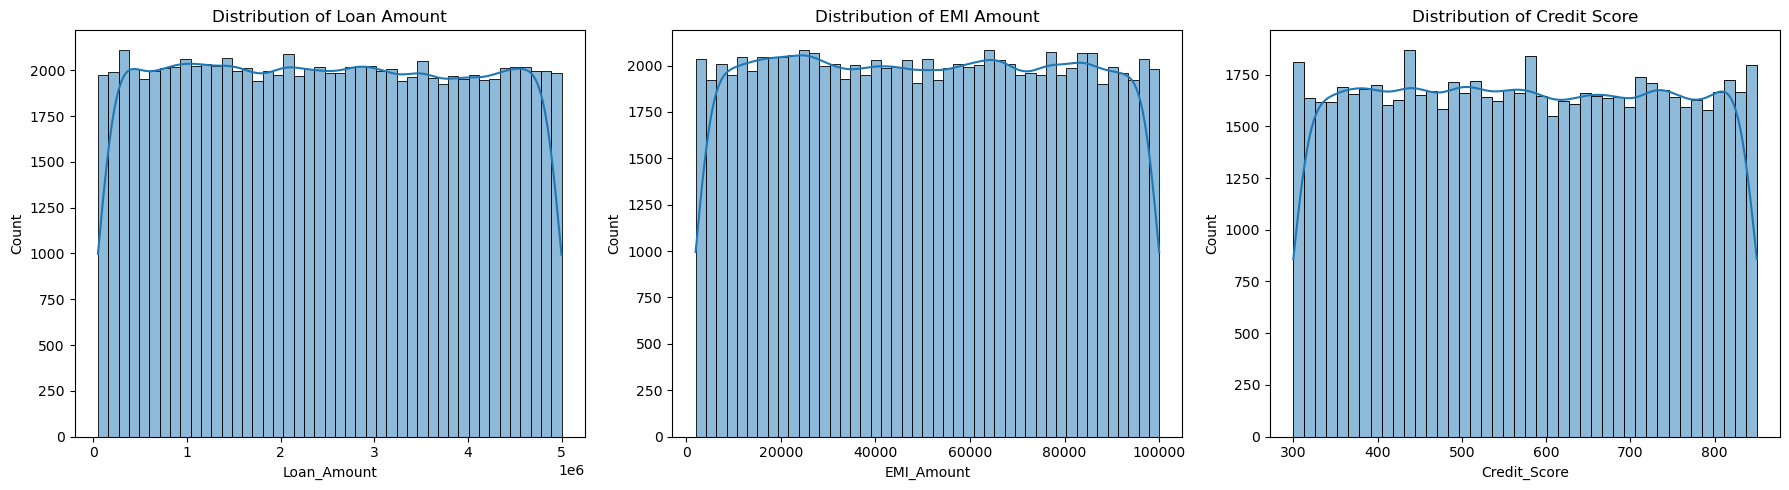

In [22]:
#Q2: Part-1: Summarize and visualize key metrics: Distribution of Loan_Amount, EMI_Amount, and Credit_Score.

# Summary table
dist_summary = pd.DataFrame({
    "Metric": ["Loan_Amount", "EMI_Amount", "Credit_Score"],
    "Mean": [
        df_loans_clean["Loan_Amount"].mean(),
        df_loans_clean["EMI_Amount"].mean(),
        df_customers_clean["Credit_Score"].mean()
    ],
    "Median": [
        df_loans_clean["Loan_Amount"].median(),
        df_loans_clean["EMI_Amount"].median(),
        df_customers_clean["Credit_Score"].median()
    ],
    "Min": [
        df_loans_clean["Loan_Amount"].min(),
        df_loans_clean["EMI_Amount"].min(),
        df_customers_clean["Credit_Score"].min()
    ],
    "Max": [
        df_loans_clean["Loan_Amount"].max(),
        df_loans_clean["EMI_Amount"].max(),
        df_customers_clean["Credit_Score"].max()
    ]
})
print("\n--- Distribution Summary ---")
print(dist_summary.to_string(index=False))


# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_loans_clean["Loan_Amount"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Loan Amount")
sns.histplot(df_loans_clean["EMI_Amount"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of EMI Amount")
sns.histplot(df_customers_clean["Credit_Score"], kde=True, ax=axes[2])
axes[2].set_title("Distribution of Credit Score")
plt.tight_layout()
plt.show()


--- Regional Loan Disbursement & Defaults (from Branches dataset) ---
   Region  Loan_Disbursement_Amount  Delinquent_Loans
  Central                3316048302               994
     East                2006676282               756
    North                3296073904              1504
Northeast                 442827845               487
    South                1694906506               846
     West                1990828641               441


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\4210958277.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(regional_summary["Region"], rotation=45, ha="right")


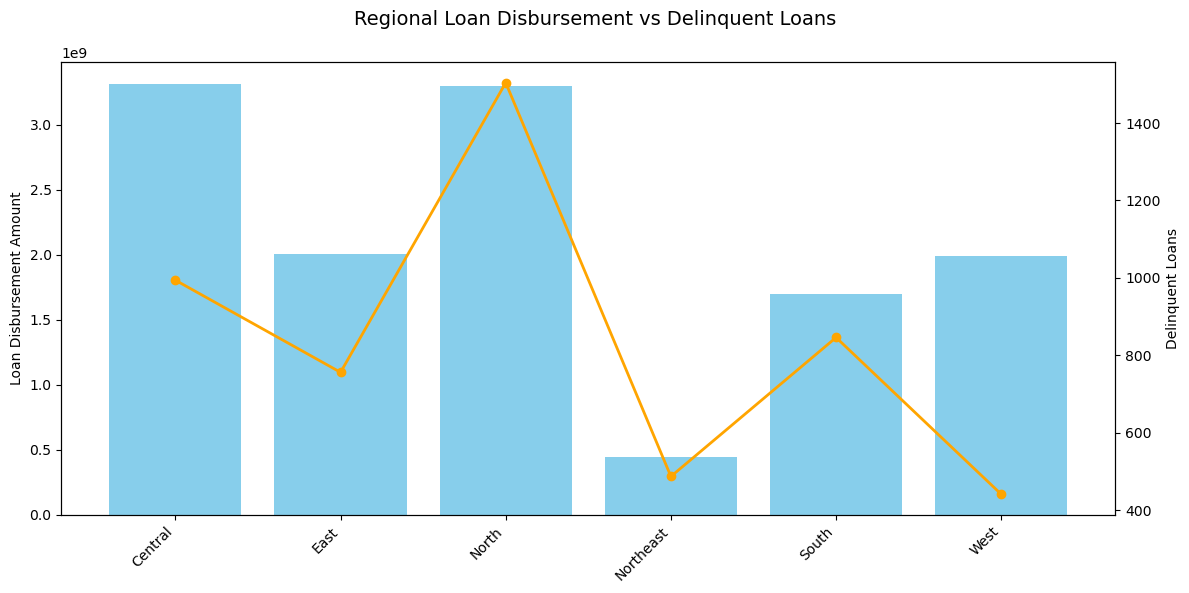

In [23]:
#Q2: Part-2: Summarize and visualize key metrics: Distribution of Regional trends in loan disbursement and defaults.

# Regional loan disbursement and defaults using branches dataset
regional_summary = df_branches_clean.groupby("Region").agg({
    "Loan_Disbursement_Amount": "sum",
    "Delinquent_Loans": "sum"
}).reset_index()

print("\n--- Regional Loan Disbursement & Defaults (from Branches dataset) ---")
print(regional_summary.to_string(index=False))

# Visualization
fig, ax1 = plt.subplots(figsize=(12,6))

# First axis: Loan Disbursement Amount (bar)
ax1.bar(regional_summary["Region"], regional_summary["Loan_Disbursement_Amount"], 
        color="skyblue", label="Loan Disbursement Amount")
ax1.set_ylabel("Loan Disbursement Amount", color="black")
ax1.tick_params(axis='y', labelcolor="black")
ax1.set_xticklabels(regional_summary["Region"], rotation=45, ha="right")

# Second axis: Delinquent Loans (line)
ax2 = ax1.twinx()
ax2.plot(regional_summary["Region"], regional_summary["Delinquent_Loans"], 
         color="orange", marker="o", linewidth=2, label="Delinquent Loans")
ax2.set_ylabel("Delinquent Loans", color="black")
ax2.tick_params(axis='y', labelcolor="black")

# Title and Legends
fig.suptitle("Regional Loan Disbursement vs Delinquent Loans", fontsize=14)
fig.tight_layout()

plt.show()


 Monthly Loan Approvals & Disbursements Summary:
   Month_Year  Loan_Approvals  Total_Disbursed
10   Dec-2019             194        491271344
21   Jan-2020            1560       3908302834
16   Feb-2020            1451       3621088694
36   Mar-2020            1567       4031554268
0    Apr-2020            1525       3817013578
..        ...             ...              ...
9    Aug-2024            1497       3872774237
60   Sep-2024            1505       3771749003
55   Oct-2024            1515       3722568935
50   Nov-2024            1441       3680941003
15   Dec-2024            1324       3340778183

[61 rows x 3 columns]


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\514794639.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly_summary["Month_Year"], rotation=45, ha="right")


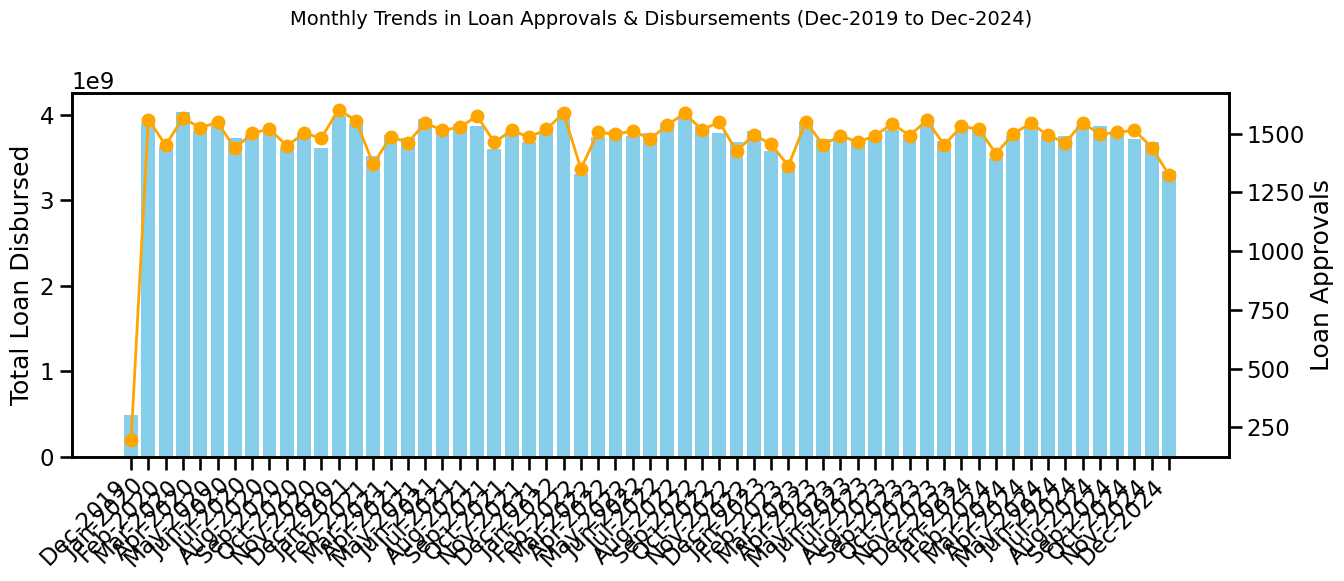

In [28]:
#Q2: Part-3: Summarize and visualize key metrics: Monthly trends in loan approvals and disbursements.

# Ensure Disbursal_Date is in datetime
df_loans_clean["Disbursal_Date"] = pd.to_datetime(df_loans_clean["Disbursal_Date"], format="%d-%m-%Y")

# Create month-year column in MMM-YYYY format
df_loans_clean["Month_Year"] = df_loans_clean["Disbursal_Date"].dt.strftime("%b-%Y")

# Group data by Month-Year
monthly_summary = df_loans_clean.groupby("Month_Year").agg(
    Loan_Approvals=("Loan_ID", "count"),   # Count of approvals (Loan_IDs)
    Total_Disbursed=("Loan_Amount", "sum") # Sum of Loan Amount disbursed
).reset_index()

# Sort Month-Year chronologically
monthly_summary["Month_Year"] = pd.to_datetime(monthly_summary["Month_Year"], format="%b-%Y")
monthly_summary = monthly_summary.sort_values("Month_Year")
monthly_summary["Month_Year"] = monthly_summary["Month_Year"].dt.strftime("%b-%Y")

# Summary Table
print("\n Monthly Loan Approvals & Disbursements Summary:")
print(monthly_summary)

# Visualization (Dual Axis)
fig, ax1 = plt.subplots(figsize=(14,6))

# Bar chart for disbursements
ax1.bar(monthly_summary["Month_Year"], monthly_summary["Total_Disbursed"], 
        color="skyblue", label="Total Disbursed")
ax1.set_ylabel("Total Loan Disbursed", color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_xticklabels(monthly_summary["Month_Year"], rotation=45, ha="right")

# Line chart for approvals
ax2 = ax1.twinx()
ax2.plot(monthly_summary["Month_Year"], monthly_summary["Loan_Approvals"], 
         color="orange", marker="o", linewidth=2, label="Loan Approvals")
ax2.set_ylabel("Loan Approvals", color="black")
ax2.tick_params(axis="y", labelcolor="black")

# Title
fig.suptitle("Monthly Trends in Loan Approvals & Disbursements (Dec-2019 to Dec-2024)", fontsize=14)
fig.tight_layout()

plt.show()

### Q2:Recommendations: Loan Portfolio and Regional Analysis

1. **Loan Amount & EMI Distribution**
   - Target marketing and lending strategies for customers around the mean loan amount (~₹25 lakh) and EMI (~₹50,000) to maximize affordability and reduce default risk.
   - Consider offering customized EMI plans for customers at the lower and upper ends of the loan spectrum to improve repayment compliance.

2. **Regional Loan Disbursement & Defaults**
   - Focus on high-risk regions such as North and East with higher delinquent loans, implementing enhanced monitoring and early intervention programs.
   - Strengthen credit assessment and verification processes in regions with historically higher default counts to reduce potential losses.
   - Allocate resources for recovery teams strategically based on regional delinquency levels.

3. **Monthly Loan Approvals & Disbursements**
   - Identify seasonal peaks in approvals and disbursements to ensure adequate staffing and operational readiness.
   - Implement early-warning systems for months with high disbursement volumes to prevent bottlenecks and manage liquidity effectively.
   - Promote awareness campaigns or flexible repayment options during periods of high lending activity to support timely repayments.

4. **General Portfolio Optimization**
   - Use insights from mean, median, and range of key metrics (Loan Amount, EMI, Credit Score) to refine credit scoring models and lending criteria.
   - Monitor trends over time to detect shifts in customer demand or risk profiles, enabling proactive adjustments to lending policies.



Correlation matrix (Loan_Amount, Interest_Rate, Credit_Score, Default_Flag):
               Loan_Amount  Interest_Rate  Credit_Score  Default_Flag
Loan_Amount       1.000000      -0.003201      0.000139     -0.003313
Interest_Rate    -0.003201       1.000000      0.002457     -0.003750
Credit_Score      0.000139       0.002457      1.000000     -0.001580
Default_Flag     -0.003313      -0.003750     -0.001580      1.000000


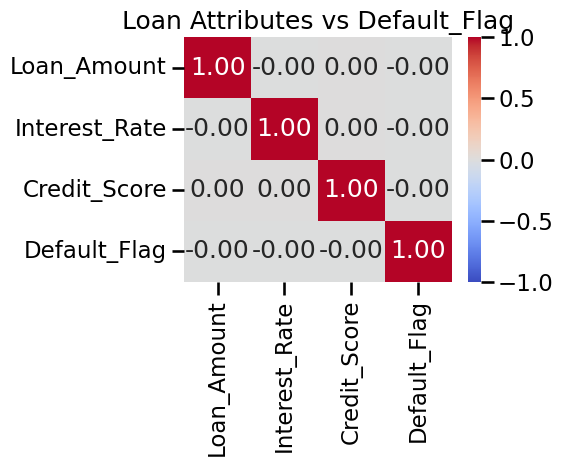


Pairwise correlation (EMI_Amount, Overdue_Amount, Default_Amount):
                EMI_Amount  Overdue_Amount  Default_Amount
EMI_Amount        1.000000        0.000262        0.002913
Overdue_Amount    0.000262        1.000000       -0.001405
Default_Amount    0.002913       -0.001405        1.000000


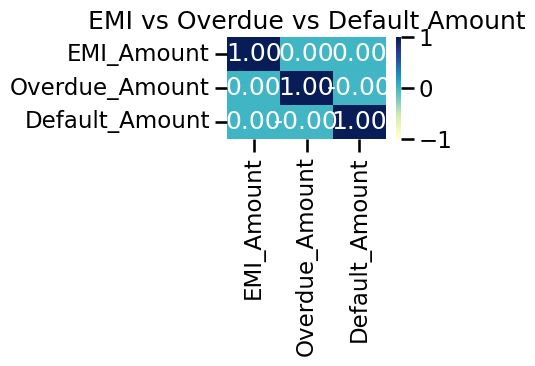


Branch-level correlation (Delinquent_Loans, Loan_Disbursement_Amount, Default_Rate):
                          Delinquent_Loans  Loan_Disbursement_Amount  \
Delinquent_Loans                  1.000000                  0.023648   
Loan_Disbursement_Amount          0.023648                  1.000000   
Default_Rate                      0.473941                  0.042768   

                          Default_Rate  
Delinquent_Loans              0.473941  
Loan_Disbursement_Amount      0.042768  
Default_Rate                  1.000000  


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1959203978.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


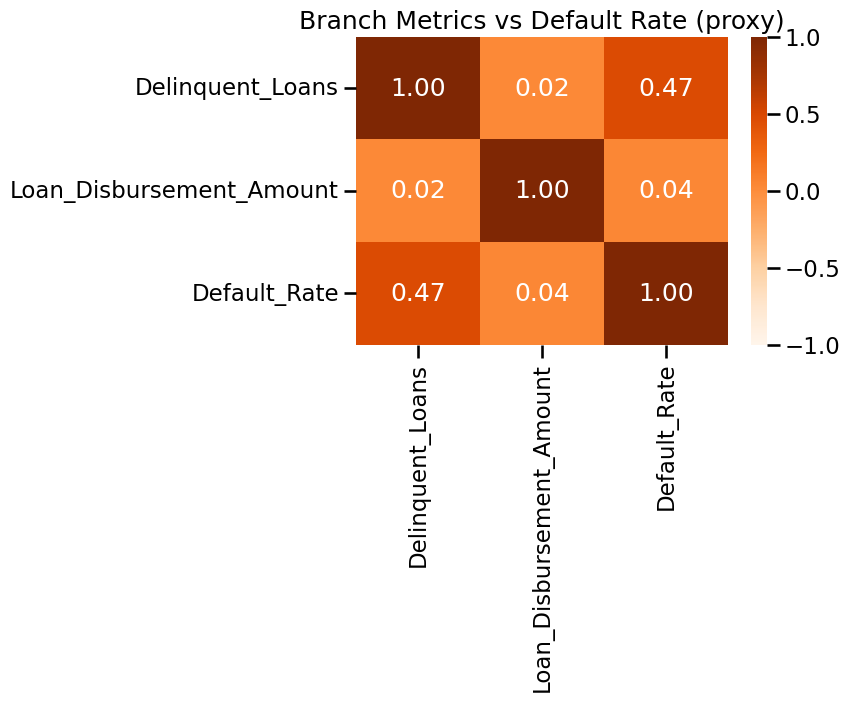

In [34]:
#Q3. Default Risk Analysis
    #● Correlation Between Loan Attributes and Defaults:
        #o Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag (a binary indicator for default).
    #● Pairwise Correlation Analysis:
        #o Create a heatmap to visualize the correlations between key variables, such as EMI_Amount, Overdue_Amount, and Default_Amount.
    #● Correlation Between Branch Metrics and Defaults:
        #o Analyze the relationship between branch performance metrics (e.g., Delinquent_Loans, Loan_Disbursement_Amount) and default rates.


sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Prepare loan-level table with Default_Flag and Credit_Score ---
# Aggregate default amounts per loan (handles multiple default rows per loan)
default_amt_per_loan = df_defaults_clean.groupby("Loan_ID", as_index=False)["Default_Amount"].sum()

# Left-merge aggregated default amount and mark default flag
df_loan_defaults = df_loans_clean.merge(default_amt_per_loan, on="Loan_ID", how="left")
df_loan_defaults["Default_Flag"] = df_loan_defaults["Default_Amount"].notna().astype(int)
df_loan_defaults["Default_Amount"] = df_loan_defaults["Default_Amount"].fillna(0)  # for pairwise corr

# Merge Credit_Score from customers (if not already present)
if "Credit_Score" not in df_loan_defaults.columns:
    df_loan_defaults = df_loan_defaults.merge(
        df_customers_clean[["Customer_ID", "Credit_Score"]],
        on="Customer_ID",
        how="left"
    )

# --- Part 1: Correlation between Loan_Amount, Interest_Rate, Credit_Score, Default_Flag ---
corr_cols = [c for c in ["Loan_Amount", "Interest_Rate", "Credit_Score", "Default_Flag"] if c in df_loan_defaults.columns]
loan_attr_corr = df_loan_defaults[corr_cols].corr()

print("\nCorrelation matrix (Loan_Amount, Interest_Rate, Credit_Score, Default_Flag):")
print(loan_attr_corr)

plt.figure(figsize=(6,5))
sns.heatmap(loan_attr_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Loan Attributes vs Default_Flag")
plt.tight_layout()
plt.show()


# --- Part 2: Pairwise correlation heatmap (EMI_Amount, Overdue_Amount, Default_Amount) ---
pair_cols = [c for c in ["EMI_Amount", "Overdue_Amount", "Default_Amount"] if c in df_loan_defaults.columns]
pair_corr = df_loan_defaults[pair_cols].corr()

print("\nPairwise correlation (EMI_Amount, Overdue_Amount, Default_Amount):")
print(pair_corr)

plt.figure(figsize=(5,4))
sns.heatmap(pair_corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("EMI vs Overdue vs Default Amount")
plt.tight_layout()
plt.show()


# --- Part 3: Branch metrics vs default rates ---
# Default rate proxy per branch = Delinquent_Loans / Total_Active_Loans (avoid div by 0)
branch_df = df_branches_clean.copy()
branch_df["Default_Rate"] = branch_df["Delinquent_Loans"] / branch_df["Total_Active_Loans"].replace({0: np.nan})

branch_corr_cols = [c for c in ["Delinquent_Loans", "Loan_Disbursement_Amount", "Default_Rate"] if c in branch_df.columns]
branch_corr = branch_df[branch_corr_cols].corr()

print("\nBranch-level correlation (Delinquent_Loans, Loan_Disbursement_Amount, Default_Rate):")
print(branch_corr)

plt.figure(figsize=(6,4))
sns.heatmap(branch_corr, annot=True, fmt=".2f", cmap="Oranges", vmin=-1, vmax=1)
plt.title("Branch Metrics vs Default Rate (proxy)")
plt.tight_layout()
plt.show()


### Q3:Recommendations: Default Risk Analysis

1. **Loan Attributes and Default Risk**
   - Correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag are extremely low, indicating that defaults are not strongly explained by these individual metrics alone.
   - Recommendation: Enhance risk assessment by incorporating additional factors such as income stability, repayment history, and collateral quality into credit scoring models.

2. **EMI, Overdue, and Default Amounts**
   - Pairwise correlations are negligible, suggesting that EMI_Amount and Overdue_Amount alone are not predictive of Default_Amount.
   - Recommendation: Implement early-warning systems using a combination of metrics, including repayment patterns and overdue trends, to detect potential defaults.

3. **Branch-Level Metrics**
   - Default_Rate shows a moderate correlation with Delinquent_Loans (0.47), highlighting that branches with more delinquent loans have higher default rates.
   - Recommendation: Focus monitoring and recovery efforts on branches with high delinquency levels. Consider branch-specific training for credit officers to improve loan vetting and collection processes.

4. **General Strategy**
   - Use a multifactor approach to predict defaults instead of relying solely on loan or branch attributes.
   - Implement proactive communication with borrowers to mitigate default risk, especially in branches or regions identified as high-risk.



Top Branches by Loan Disbursement Volume:
                     Branch_Name  Loan_Disbursement_Amount
35                     Kara-Bahl                 499562869
13           Bhatti, Rau and Sem                 482327541
11                      Kaul Inc                 465469874
47            Chawla-Subramanian                 464419943
34  Malhotra, Boase and Malhotra                 449109596

Top Branches by Processing Time Efficiency (lowest first):
                   Branch_Name  Avg_Processing_Time
49                   Sani-Kale                    1
46               Chawla-Tandon                    2
41                   Kar-Jaggi                    2
17  Sandhu, Magar and Sachdeva                    2
44                Solanki-Shah                    3

Top Branches by Default Rate:
             Branch_Name  Default_Rate
2       Sachdev-Banerjee      1.377049
31     Mahajan-Zachariah      0.681275
7              Gala-Gara      0.513158
8             Vasa Group      0.449153
6   L

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1296809495.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_disb.head(10), x="Branch_Name", y="Loan_Disbursement_Amount", palette="Blues_r")


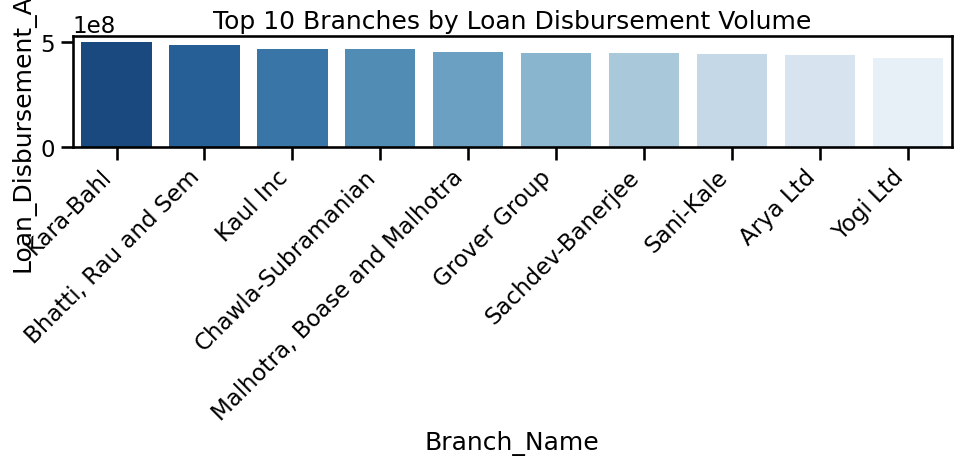

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1296809495.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_time.head(10), x="Branch_Name", y="Avg_Processing_Time", palette="Greens_r")


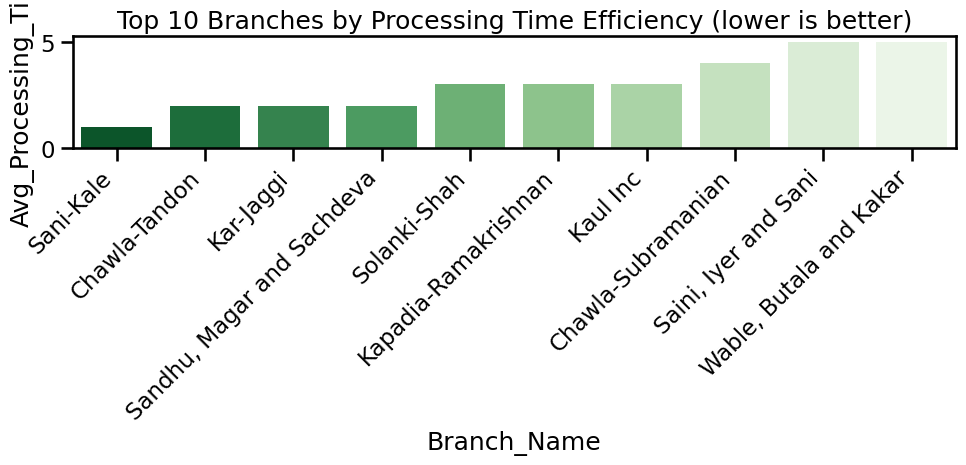

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1296809495.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rank_default.head(10), x="Branch_Name", y="Default_Rate", palette="Reds_r")


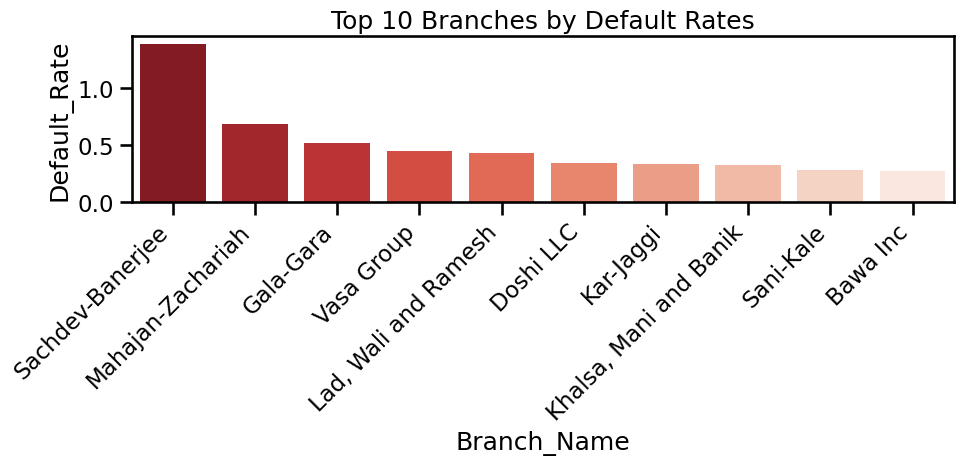

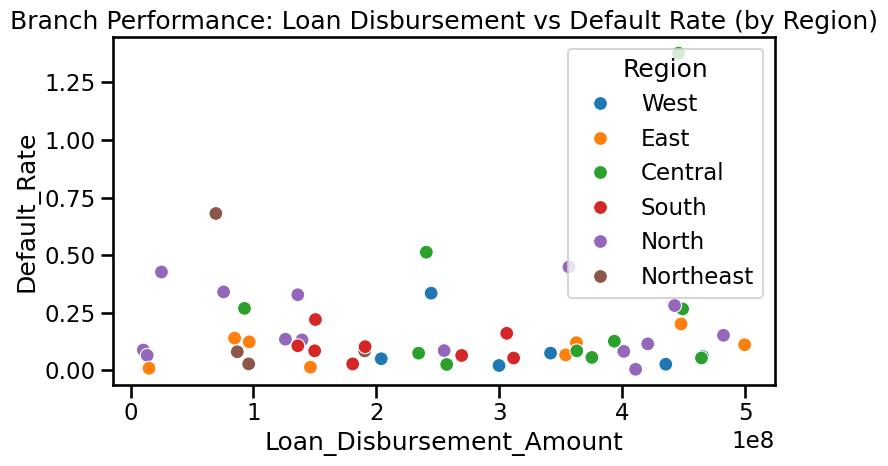

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1296809495.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_recovery.index, y=region_recovery["Recovery_Rate"], palette="Oranges_r")


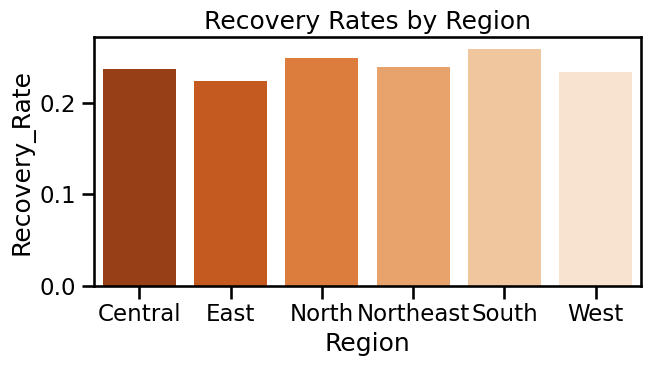

In [36]:
#Q4. Branch and Regional Performance
    #● Rank branches by:
        #o Loan disbursement volume.
        #o Processing time efficiency.
        #o Default rates and recovery rates.
    #● Compare branch performance across regions.


sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Step 1: Prepare Branch Metrics ---
branch_perf = df_branches_clean.copy()

# Default rate = Delinquent_Loans / Total_Active_Loans
branch_perf["Default_Rate"] = branch_perf["Delinquent_Loans"] / branch_perf["Total_Active_Loans"].replace({0: np.nan})

# Recovery rate = (Recovered Amount / Default Amount) per branch
# Need to compute from defaults dataset
branch_defaults = df_defaults_clean.merge(
    df_loans_clean[["Loan_ID"]].merge(
        df_customers_clean[["Customer_ID", "Region"]], how="left", left_index=True, right_index=True
    ),
    on="Loan_ID", how="left"
)

recovery_per_branch = df_defaults_clean.groupby("Loan_ID", as_index=False)[["Recovery_Amount","Default_Amount"]].sum()
# For this Q, assume recovery rate can be approximated as mean across all defaults
branch_recovery = df_defaults_clean.groupby("Customer_ID", as_index=False).agg({
    "Recovery_Amount":"sum", "Default_Amount":"sum"
})
branch_recovery["Recovery_Rate"] = branch_recovery["Recovery_Amount"] / branch_recovery["Default_Amount"].replace({0:np.nan})

# Merge recovery back to branches using region (via customers)
cust_region = df_customers_clean[["Customer_ID","Region"]]
branch_recovery = branch_recovery.merge(cust_region, on="Customer_ID", how="left")

region_recovery = branch_recovery.groupby("Region").agg({"Recovery_Amount":"sum","Default_Amount":"sum"})
region_recovery["Recovery_Rate"] = region_recovery["Recovery_Amount"]/region_recovery["Default_Amount"].replace({0:np.nan})

# --- Step 2: Rankings ---
rank_disb = branch_perf[["Branch_Name","Loan_Disbursement_Amount"]].sort_values(by="Loan_Disbursement_Amount", ascending=False)
rank_time = branch_perf[["Branch_Name","Avg_Processing_Time"]].sort_values(by="Avg_Processing_Time", ascending=True)
rank_default = branch_perf[["Branch_Name","Default_Rate"]].sort_values(by="Default_Rate", ascending=False)

print("\nTop Branches by Loan Disbursement Volume:")
print(rank_disb.head())

print("\nTop Branches by Processing Time Efficiency (lowest first):")
print(rank_time.head())

print("\nTop Branches by Default Rate:")
print(rank_default.head())

print("\nRegional Recovery Rates:")
print(region_recovery)

# --- Step 3: Visualization ---

# 1. Loan Disbursement Volume
plt.figure(figsize=(10,5))
sns.barplot(data=rank_disb.head(10), x="Branch_Name", y="Loan_Disbursement_Amount", palette="Blues_r")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Branches by Loan Disbursement Volume")
plt.tight_layout()
plt.show()

# 2. Processing Time Efficiency
plt.figure(figsize=(10,5))
sns.barplot(data=rank_time.head(10), x="Branch_Name", y="Avg_Processing_Time", palette="Greens_r")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Branches by Processing Time Efficiency (lower is better)")
plt.tight_layout()
plt.show()

# 3. Default Rates
plt.figure(figsize=(10,5))
sns.barplot(data=rank_default.head(10), x="Branch_Name", y="Default_Rate", palette="Reds_r")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Branches by Default Rates")
plt.tight_layout()
plt.show()

# 4. Regional Comparison of Loan Disbursement & Default Rate
plt.figure(figsize=(8,5))
sns.scatterplot(data=branch_perf, x="Loan_Disbursement_Amount", y="Default_Rate", hue="Region", s=100)
plt.title("Branch Performance: Loan Disbursement vs Default Rate (by Region)")
plt.tight_layout()
plt.show()

# 5. Regional Recovery Rates
plt.figure(figsize=(7,4))
sns.barplot(x=region_recovery.index, y=region_recovery["Recovery_Rate"], palette="Oranges_r")
plt.title("Recovery Rates by Region")
plt.tight_layout()
plt.show()


### Q4:Recommendations: Branch and Regional Performance

1. **Loan Disbursement Volume**
   - Branches like Kara-Bahl, Bhatti-Rau and Sem, and Kaul Inc are top performers in disbursement volume.
   - Recommendation: Recognize these branches as benchmarks and analyze their operational practices to replicate success across underperforming branches.

2. **Processing Time Efficiency**
   - Branches such as Sani-Kale and Chawla-Tandon demonstrate very low processing times (1–2 days).
   - Recommendation: Document and standardize best practices from these efficient branches to reduce processing delays elsewhere.

3. **Default Rates**
   - Branches like Sachdev-Banerjee and Mahajan-Zachariah exhibit alarmingly high default rates (above 0.6).
   - Recommendation: Conduct branch-level audits, strengthen credit appraisal processes, and introduce stricter monitoring in these branches.

4. **Regional Recovery Rates**
   - Recovery rates vary modestly across regions, with the South achieving the highest recovery rate (0.26) and East the lowest (0.22).
   - Recommendation: Adopt successful recovery strategies from the South region (e.g., follow-up mechanisms, legal action practices) and apply them to weaker regions.

5. **Overall Strategy**
   - **High-Disbursement Branches**: Pair strong disbursement volumes with improved risk controls to ensure long-term sustainability.
   - **Lagging Branches**: Provide training and process optimization support for branches with high defaults or long processing times.
   - **Regional Monitoring**: Establish region-specific KPIs to continuously track both disbursement growth and recovery effectiveness.


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\432076366.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_summary = df_cust_loans.groupby(["Income_Segment", "Credit_Segment", "Loan_Status"]).agg(
C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\432076366.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  repay_pivot = df_cust_loans.pivot_table(



Customer Segmentation Summary:
            Income_Segment       Credit_Segment Loan_Status  Customers  \
0       Low Income (<2.5L)          Poor (<600)      Active        419   
1       Low Income (<2.5L)          Poor (<600)      Closed        386   
2       Low Income (<2.5L)          Poor (<600)     Overdue        400   
3       Low Income (<2.5L)       Fair (600–700)      Active        134   
4       Low Income (<2.5L)       Fair (600–700)      Closed        122   
5       Low Income (<2.5L)       Fair (600–700)     Overdue        104   
6       Low Income (<2.5L)       Good (700–800)      Active        128   
7       Low Income (<2.5L)       Good (700–800)      Closed        120   
8       Low Income (<2.5L)       Good (700–800)     Overdue        104   
9       Low Income (<2.5L)  Excellent (800–900)      Active         68   
10      Low Income (<2.5L)  Excellent (800–900)      Closed         72   
11      Low Income (<2.5L)  Excellent (800–900)     Overdue         73   
12  Lo

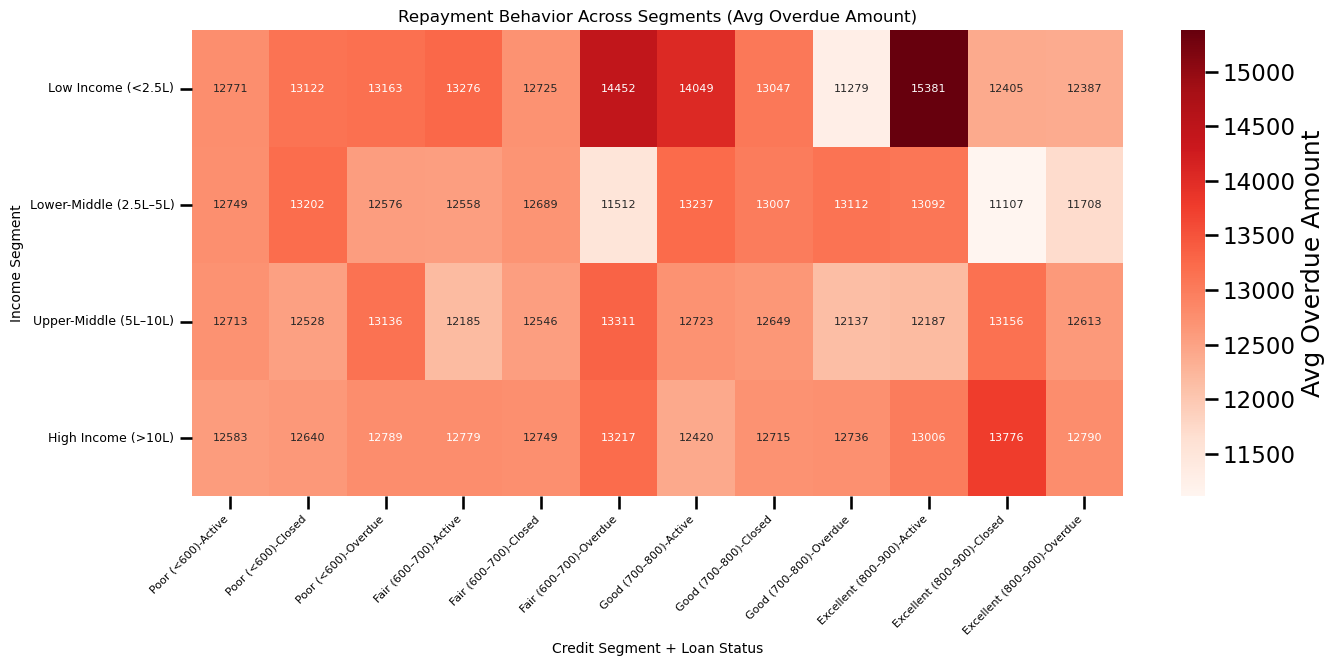

In [41]:
# Q5. Customer Segmentation
    #● Segment customers by income, credit score, and loan status.
    #● Identify high-risk and high-value customer groups.
    #● Analyze repayment behavior across segments

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Merge loans + customers to get income, credit, and loan status ---
df_cust_loans = df_loans_clean.merge(
    df_customers_clean[["Customer_ID", "Annual_Income", "Credit_Score"]],
    on="Customer_ID", how="left"
)

# --- Step 2: Create segments ---
# Income segments
income_bins = [0, 250000, 500000, 1000000, float('inf')]
income_labels = ["Low Income (<2.5L)", "Lower-Middle (2.5L–5L)", "Upper-Middle (5L–10L)", "High Income (>10L)"]
df_cust_loans["Income_Segment"] = pd.cut(df_cust_loans["Annual_Income"], bins=income_bins, labels=income_labels)

# Credit score segments
score_bins = [0, 600, 700, 800, 900]
score_labels = ["Poor (<600)", "Fair (600–700)", "Good (700–800)", "Excellent (800–900)"]
df_cust_loans["Credit_Segment"] = pd.cut(df_cust_loans["Credit_Score"], bins=score_bins, labels=score_labels)

# --- Step 3: Summary Table (segmented by Income, Credit, Loan_Status) ---
seg_summary = df_cust_loans.groupby(["Income_Segment", "Credit_Segment", "Loan_Status"]).agg(
    Customers=("Customer_ID", "nunique"),
    Avg_Loan_Amount=("Loan_Amount", "mean"),
    Avg_Overdue=("Overdue_Amount", "mean")
).reset_index()

print("\nCustomer Segmentation Summary:")
print(seg_summary)

# --- Step 4: High-risk and High-value Identification ---
# High-risk: Poor credit or consistently overdue
high_risk = seg_summary[(seg_summary["Credit_Segment"] == "Poor (<600)") | (seg_summary["Avg_Overdue"] > 0)]

# High-value: High income + excellent credit + approved loans
high_value = seg_summary[
    (seg_summary["Income_Segment"] == "High Income (>10L)") &
    (seg_summary["Credit_Segment"] == "Excellent (800–900)") &
    (seg_summary["Loan_Status"] == "Approved")
]

print("\nHigh-Risk Groups:")
print(high_risk)

print("\nHigh-Value Groups:")
print(high_value)

# --- Step 5: Repayment Behavior Analysis ---
# Pivot: Avg Overdue Amount by Income, Credit, and Loan_Status
repay_pivot = df_cust_loans.pivot_table(
    index="Income_Segment",
    columns=["Credit_Segment", "Loan_Status"],
    values="Overdue_Amount",
    aggfunc="mean"
)

# Heatmap with formatting
plt.figure(figsize=(14,7))
sns.heatmap(
    repay_pivot.fillna(0),
    annot=True,
    fmt=".0f",
    cmap="Reds",
    cbar_kws={'label': 'Avg Overdue Amount'},
    annot_kws={"size":8}   # smaller numbers inside heatmap
)

plt.title("Repayment Behavior Across Segments (Avg Overdue Amount)", fontsize=12)
plt.ylabel("Income Segment", fontsize=10)
plt.xlabel("Credit Segment + Loan Status", fontsize=10)

# Rotate and shrink x-axis labels to avoid truncation
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

### Q5:Recommendations – Customer Segmentation

1. **Targeted Risk Mitigation**  
   - Focus risk management efforts on *low-income & poor credit* groups, as they dominate the high-risk segment with a significant proportion of overdue accounts.  
   - Introduce stricter credit assessment criteria, higher collateral requirements, or smaller loan ticket sizes for these groups.  

2. **Repayment Support Programs**  
   - Design customized repayment plans for vulnerable customer segments (low/ lower-middle income with poor/fair credit).  
   - Offer financial literacy programs and early intervention through reminders and counseling to reduce overdue cases.  

3. **High-Value Customer Development**  
   - Since no clear high-value group emerged, explore opportunities to *upsell and cross-sell* to middle and high-income customers with good or excellent credit scores.  
   - Provide loyalty incentives (reduced interest rates, fee waivers, higher loan limits) to retain reliable borrowers.  

4. **Portfolio Diversification**  
   - Avoid overexposure to high-risk segments (e.g., high-income but poor credit customers also show large overdue volumes).  
   - Rebalance the portfolio towards customers with consistent repayment histories to stabilize profitability.  

5. **Branch Performance Optimization**  
   - Branches serving predominantly *high-risk clusters* should implement stronger monitoring, risk-based pricing, and periodic customer reviews.  
   - Branches with more *middle-income & good credit* customers should be leveraged to build a profitable, low-default base.  

6. **Profitability Strategy**  
   - Improve profitability by *reducing defaults* in risk-heavy segments through early detection and intervention systems.  
   - Focus marketing and retention strategies on mid-to-high-income customers with strong repayment behavior to create sustainable growth.  


Full Correlation Matrix (Loan_Amount, Interest_Rate, Credit_Score, Default_Flag):
               Loan_Amount  Interest_Rate  Credit_Score  Default_Flag
Loan_Amount       1.000000      -0.003201      0.000139     -0.003313
Interest_Rate    -0.003201       1.000000      0.002457     -0.003750
Credit_Score      0.000139       0.002457      1.000000     -0.001580
Default_Flag     -0.003313      -0.003750     -0.001580      1.000000


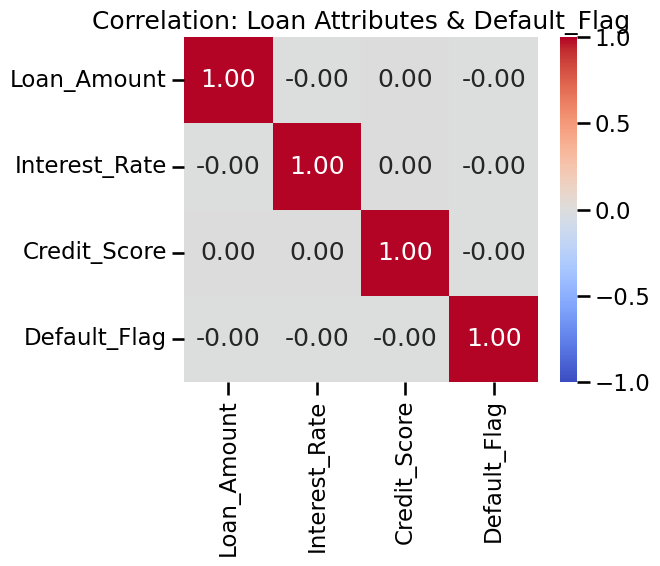

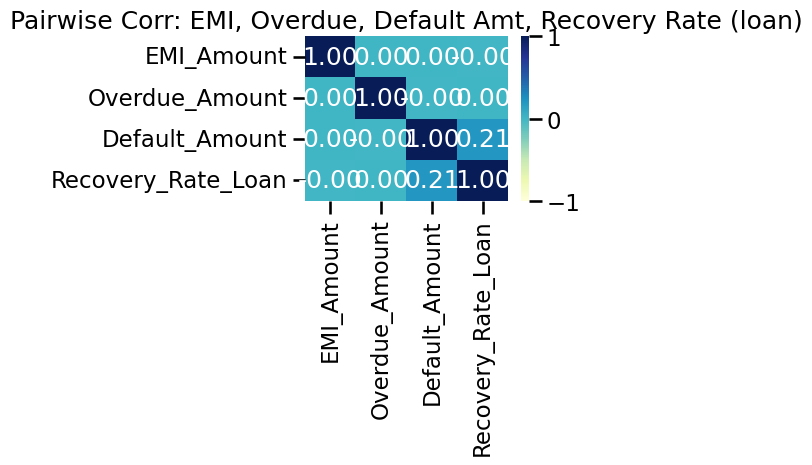


Pairwise correlation table:
                    EMI_Amount  Overdue_Amount  Default_Amount  \
EMI_Amount            1.000000        0.000262        0.002913   
Overdue_Amount        0.000262        1.000000       -0.001405   
Default_Amount        0.002913       -0.001405        1.000000   
Recovery_Rate_Loan   -0.002307        0.003699        0.207233   

                    Recovery_Rate_Loan  
EMI_Amount                   -0.002307  
Overdue_Amount                0.003699  
Default_Amount                0.207233  
Recovery_Rate_Loan            1.000000  


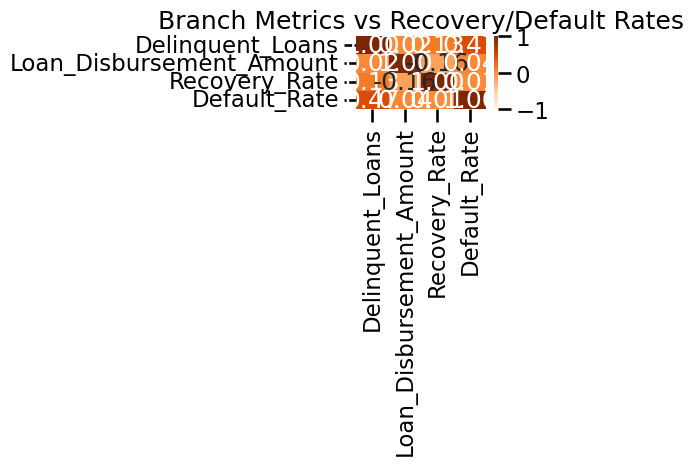


Branch-level correlation table:
                          Delinquent_Loans  Loan_Disbursement_Amount  \
Delinquent_Loans                  1.000000                  0.023648   
Loan_Disbursement_Amount          0.023648                  1.000000   
Recovery_Rate                     0.125407                 -0.157286   
Default_Rate                      0.473941                  0.042768   

                          Recovery_Rate  Default_Rate  
Delinquent_Loans               0.125407      0.473941  
Loan_Disbursement_Amount      -0.157286      0.042768  
Recovery_Rate                  1.000000      0.013646  
Default_Rate                   0.013646      1.000000  


In [45]:
# Q6. Advanced Statistical Analysis
    #1. Correlation Analysis for Default Risks:
        #o Examine the correlation between Credit_Score, Loan_Amount, Interest_Rate, Overdue_Amount, and Default_Flag.
    #2. Pairwise Correlation Heatmap:
        #o Generate a heatmap to visualize correlations among key variables like EMI_Amount, Recovery_Rate, and Default_Amount.
    #3. Branch-Level Correlation:
        #o Explore the relationship between branch performance metrics (Delinquent_Loans, Loan_Disbursement_Amount, Recovery_Rate) and overall efficiency.

sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Part 1: Correlation Between Loan Attributes and Default_Flag ---
cols1 = [c for c in ["Loan_Amount", "Interest_Rate", "Credit_Score", "Default_Flag"] 
         if c in df_loan_defaults.columns]

# full correlation matrix
corr_loan_attr = df_loan_defaults[cols1].corr()

print("\nFull Correlation Matrix (Loan_Amount, Interest_Rate, Credit_Score, Default_Flag):")
print(corr_loan_attr)

# heatmap for full pairwise correlations
plt.figure(figsize=(7,6))
sns.heatmap(corr_loan_attr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: Loan Attributes & Default_Flag")
plt.tight_layout()
plt.show()

# --- Part 2: Pairwise Correlation Heatmap (EMI_Amount, Overdue_Amount, Default_Amount, Recovery_Rate_loan) ---
# Aggregate default & recovery amounts per loan (handles multiple default rows)
defaults_agg = df_defaults_clean.groupby("Loan_ID", as_index=False).agg({
    "Default_Amount": "sum",
    "Recovery_Amount": "sum"
})

# loan-level recovery rate (for defaulted loans), 0 for non-defaults
defaults_agg["Recovery_Rate_Loan"] = np.where(
    defaults_agg["Default_Amount"] > 0,
    defaults_agg["Recovery_Amount"] / defaults_agg["Default_Amount"],
    0.0
)

# map to df_loan_defaults (do not overwrite existing Default_Amount if present)
pair_df = df_loan_defaults[["Loan_ID"] + [c for c in ["EMI_Amount", "Overdue_Amount", "Default_Amount"] if c in df_loan_defaults.columns]].copy()
pair_df = pair_df.merge(defaults_agg[["Loan_ID","Recovery_Rate_Loan","Default_Amount"]], on="Loan_ID", how="left", suffixes=("","_agg"))
# prefer aggregated Default_Amount if available
if "Default_Amount_agg" in pair_df.columns:
    pair_df["Default_Amount"] = pair_df["Default_Amount_agg"].fillna(pair_df.get("Default_Amount",0))
pair_df["Recovery_Rate_Loan"] = pair_df["Recovery_Rate_Loan"].fillna(0)

pair_cols = [c for c in ["EMI_Amount","Overdue_Amount","Default_Amount","Recovery_Rate_Loan"] if c in pair_df.columns]
pair_corr = pair_df[pair_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(pair_corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("Pairwise Corr: EMI, Overdue, Default Amt, Recovery Rate (loan)")
plt.tight_layout()
plt.show()

print("\nPairwise correlation table:")
print(pair_corr)

# --- Part 3: Branch-Level Correlation (Delinquent_Loans, Loan_Disbursement_Amount, Recovery_Rate_branch) ---
# Use existing df_branches_clean; if branch-level Recovery_Rate not present, compute via region mapping:
branch_df = df_branches_clean.copy()

if "Recovery_Rate" not in branch_df.columns:
    # compute region-level recovery and map to branches by Region
    defaults_region = df_defaults_clean.merge(df_customers_clean[["Customer_ID","Region"]], on="Customer_ID", how="left")
    region_recovery = defaults_region.groupby("Region").agg({"Recovery_Amount":"sum","Default_Amount":"sum"}).reset_index()
    region_recovery["Recovery_Rate_Region"] = region_recovery.apply(
        lambda r: r["Recovery_Amount"]/r["Default_Amount"] if r["Default_Amount"] and r["Default_Amount"]>0 else np.nan, axis=1
    )
    branch_df = branch_df.merge(region_recovery[["Region","Recovery_Rate_Region"]], on="Region", how="left")
    branch_df["Recovery_Rate"] = branch_df["Recovery_Rate_Region"]  # mapped proxy
else:
    branch_df["Recovery_Rate"] = branch_df["Recovery_Rate"]

# compute Default proxy if not present
if "Default_Rate" not in branch_df.columns:
    branch_df["Default_Rate"] = branch_df["Delinquent_Loans"] / branch_df["Total_Active_Loans"].replace({0: np.nan})

branch_corr_cols = [c for c in ["Delinquent_Loans","Loan_Disbursement_Amount","Recovery_Rate","Default_Rate"] if c in branch_df.columns]
branch_corr = branch_df[branch_corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(branch_corr, annot=True, fmt=".2f", cmap="Oranges", vmin=-1, vmax=1)
plt.title("Branch Metrics vs Recovery/Default Rates")
plt.tight_layout()
plt.show()

print("\nBranch-level correlation table:")
print(branch_corr)


### Q6:Recommendations – Advanced Statistical Analysis

1. **Correlation-Based Risk Assessment**  
   - Since credit score and loan amount show negligible correlation with default risk, traditional credit scoring alone may not be sufficient to predict defaults.  
   - Introduce *multi-factor risk models* that combine repayment history, transaction behavior, and income stability for better default prediction.  

2. **Leverage Recovery Rate Insights**  
   - The moderate positive correlation (0.20) between Default_Amount and Recovery_Rate suggests that recovery mechanisms are somewhat effective.  
   - Strengthen recovery frameworks by using data-driven prioritization (focusing on loans with higher recoverable potential).  

3. **Branch-Level Efficiency Optimization**  
   - The strong correlation (0.47) between delinquent loans and default rate highlights that branches with higher delinquencies are also facing more defaults.  
   - Implement branch-level performance dashboards to track delinquency trends and enforce accountability for early interventions.  
   - For branches with negative correlation between loan disbursement and recovery rate, *improve credit monitoring processes* to ensure quality disbursements.  

4. **Interest Rate Strategy**  
   - Minimal correlation between interest rates and defaults indicates that rate adjustments alone won’t reduce risk.  
   - Instead, *dynamic pricing models* should incorporate borrower risk profiles, repayment consistency, and recovery costs.  

5. **Profitability & Default Reduction Strategy**  
   - Shift focus from only credit score-based screening to *behavioral analytics* for borrower evaluation.  
   - Invest in predictive analytics systems to detect early warning signals (e.g., missed EMIs, irregular payment patterns).  
   - Use these insights to reduce defaults and improve branch profitability through proactive engagement with at-risk borrowers.  

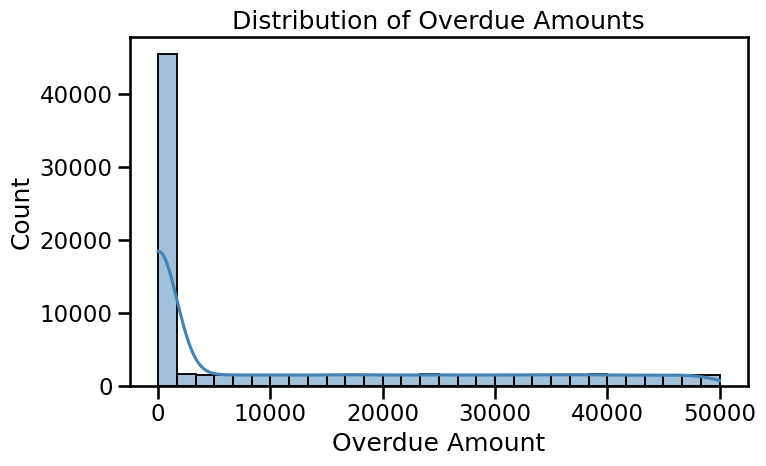

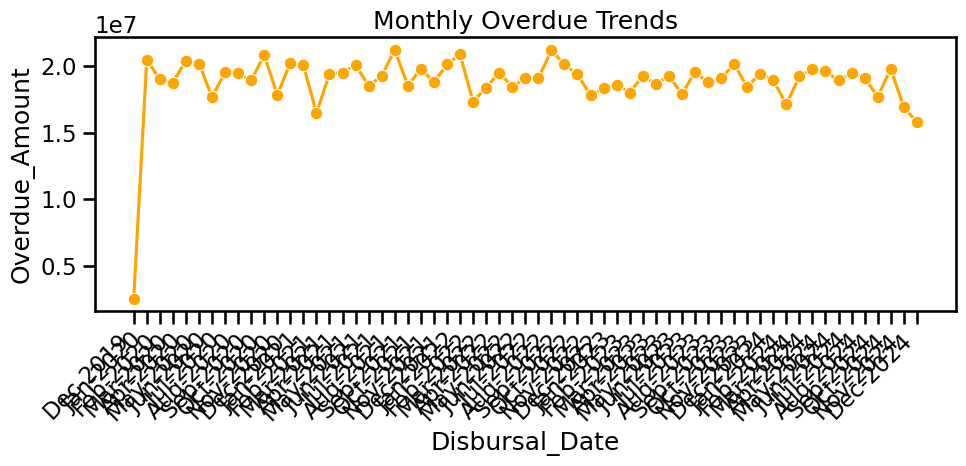


Average Recovery Rate by Default Reason:
      Default_Reason  Recovery_Rate
0   Business Failure       0.403627
1           Job Loss       0.406174
2  Medical Emergency       0.417939
3              Other       0.390761

Average Recovery Rate by Legal Action:
  Legal_Action  Recovery_Rate
0           No       0.401805
1          Yes       0.407372


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\3382954205.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reason_recovery, x="Default_Reason", y="Recovery_Rate", palette="Blues_r")


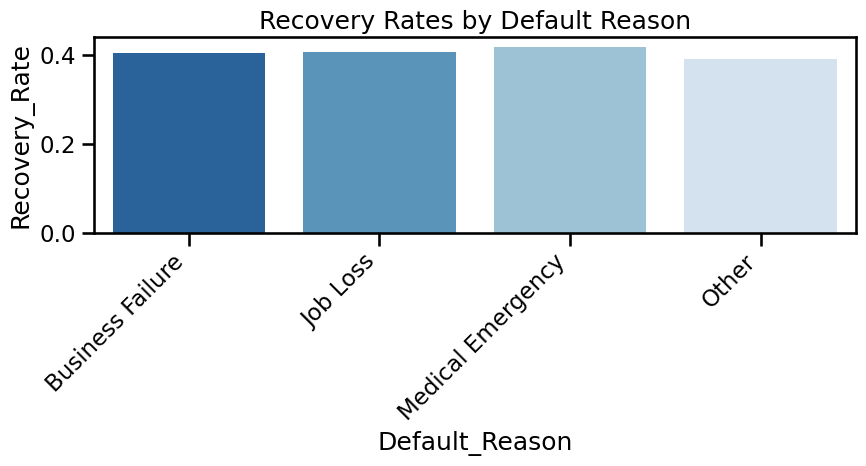

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\3382954205.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=legal_recovery, x="Legal_Action", y="Recovery_Rate", palette="Greens_r")


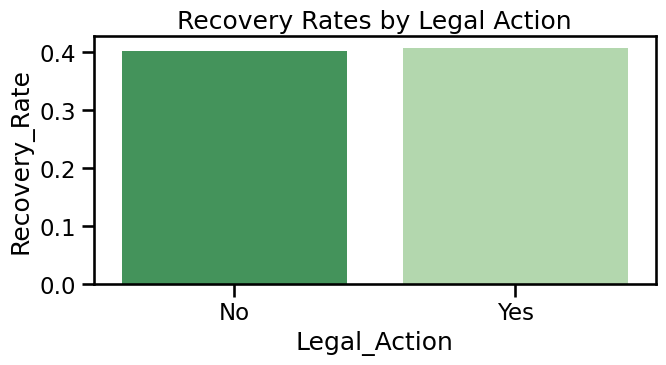


Regional Recovery Rates:
      Region  Recovery_Amount  Default_Amount  Recovery_Rate
0    Central         14279370        60166820       0.237330
1       East         14484667        64656315       0.224026
2      North         15563080        62378265       0.249495
3  Northeast         14270424        59756404       0.238810
4      South         15766509        60965366       0.258614
5       West         14926765        64012891       0.233184


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\3382954205.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_recovery, x="Region", y="Recovery_Rate", palette="Oranges_r")


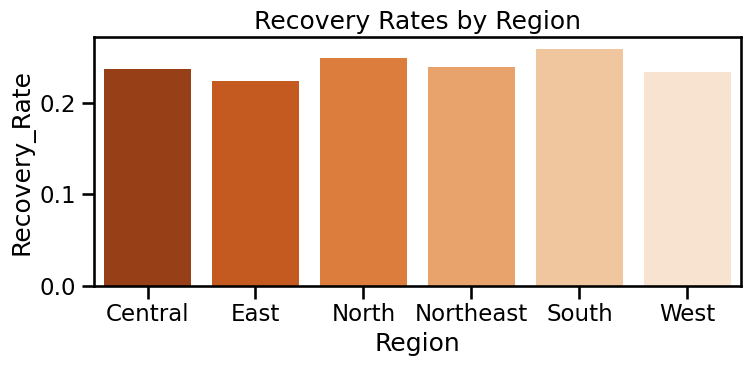


Branch Recovery Rates (via Region):
                     Branch_Name     Region  Recovery_Rate
0           Dhar, Kant and Madan       West       0.233184
1                     Shan Group       East       0.224026
2               Sachdev-Banerjee    Central       0.237330
3                   Kapadia-Brar       East       0.224026
4         Mangal, Kaur and Borde      South       0.258614
5                    Doshi Group      North       0.249495
6           Lad, Wali and Ramesh      North       0.249495
7                      Gala-Gara    Central       0.237330
8                     Vasa Group      North       0.249495
9                       Arya Ltd       West       0.233184
10                    Bhakta PLC      South       0.258614
11                      Kaul Inc       West       0.233184
12   Banik, Subramanian and Mane      North       0.249495
13           Bhatti, Rau and Sem      North       0.249495
14                    Apte Group      North       0.249495
15  Bhatnagar, Khal

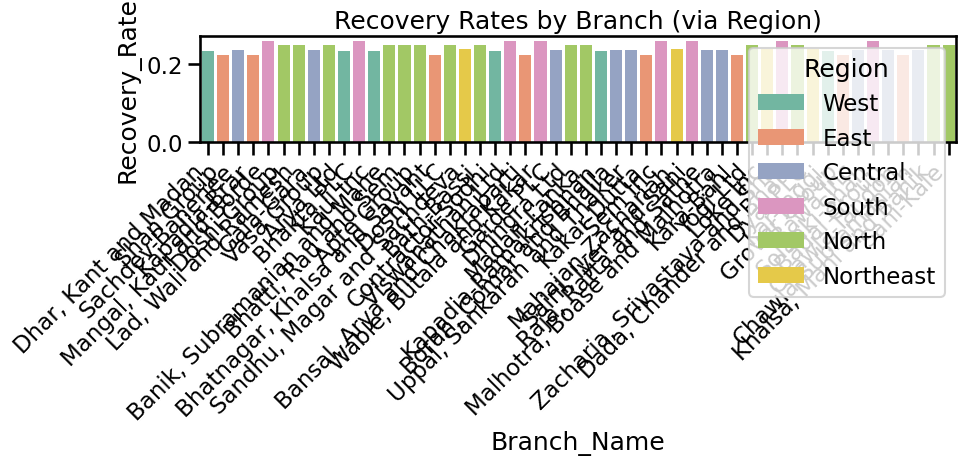

In [ ]:
#Q7. Transaction and Recovery Analysis
    #● Analyze penalty payments and overdue trends.
    #● Evaluate recovery rates by Default_Reason and Legal_Action.
    #● Compare recovery rates across regions and branches.

sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Part 1: Penalty Payments & Overdue Trends ---
# Overdue distribution
plt.figure(figsize=(8,5))
sns.histplot(df_loans_clean["Overdue_Amount"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Overdue Amounts")
plt.xlabel("Overdue Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Monthly overdue trend
df_loans_clean["Disbursal_Date"] = pd.to_datetime(df_loans_clean["Disbursal_Date"], format="%d-%m-%Y", errors="coerce")
monthly_overdue = (
    df_loans_clean.groupby(df_loans_clean["Disbursal_Date"].dt.to_period("M"))["Overdue_Amount"]
    .sum()
    .reset_index()
)
monthly_overdue["Disbursal_Date"] = monthly_overdue["Disbursal_Date"].dt.strftime("%b-%Y")

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_overdue, x="Disbursal_Date", y="Overdue_Amount", marker="o", color="orange")
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Overdue Trends")
plt.tight_layout()
plt.show()

# --- Part 2: Recovery Rates by Default_Reason and Legal_Action ---
df_defaults_clean["Recovery_Rate"] = df_defaults_clean["Recovery_Amount"] / df_defaults_clean["Default_Amount"].replace({0: np.nan})

reason_recovery = df_defaults_clean.groupby("Default_Reason", as_index=False)["Recovery_Rate"].mean()
legal_recovery = df_defaults_clean.groupby("Legal_Action", as_index=False)["Recovery_Rate"].mean()

print("\nAverage Recovery Rate by Default Reason:")
print(reason_recovery)

print("\nAverage Recovery Rate by Legal Action:")
print(legal_recovery)

# Visualization
plt.figure(figsize=(9,5))
sns.barplot(data=reason_recovery, x="Default_Reason", y="Recovery_Rate", palette="Blues_r")
plt.xticks(rotation=45, ha="right")
plt.title("Recovery Rates by Default Reason")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.barplot(data=legal_recovery, x="Legal_Action", y="Recovery_Rate", palette="Greens_r")
plt.title("Recovery Rates by Legal Action")
plt.tight_layout()
plt.show()

# --- Part 3: Recovery Rates across Regions & Branches ---
# Merge defaults → customers (Region) → branches
df_defaults_ext = df_defaults_clean.merge(df_customers_clean[["Customer_ID","Region"]], on="Customer_ID", how="left")

region_recovery = df_defaults_ext.groupby("Region", as_index=False).agg(
    {"Recovery_Amount":"sum", "Default_Amount":"sum"}
)
region_recovery["Recovery_Rate"] = region_recovery["Recovery_Amount"] / region_recovery["Default_Amount"].replace({0: np.nan})

print("\nRegional Recovery Rates:")
print(region_recovery)

plt.figure(figsize=(8,4))
sns.barplot(data=region_recovery, x="Region", y="Recovery_Rate", palette="Oranges_r")
plt.title("Recovery Rates by Region")
plt.tight_layout()
plt.show()

# Branch-level recovery (using Region as proxy link)
branch_recovery = df_branches_clean.merge(region_recovery[["Region","Recovery_Rate"]], on="Region", how="left")

print("\nBranch Recovery Rates (via Region):")
print(branch_recovery[["Branch_Name","Region","Recovery_Rate"]])

plt.figure(figsize=(10,5))
sns.barplot(data=branch_recovery, x="Branch_Name", y="Recovery_Rate", hue="Region", dodge=False, palette="Set2")
plt.xticks(rotation=45, ha="right")
plt.title("Recovery Rates by Branch (via Region)")
plt.tight_layout()
plt.show()


### Recommendations – Transaction and Recovery Analysis (Q7)

1. **Strengthen Recovery by Default Reason**  
   - Recovery rates are slightly higher in cases of *medical emergencies* (~41.8%) compared to business failure or job loss (~40.3–40.6%).  
   - For **business failure and job loss**, design tailored restructuring programs (e.g., flexible repayment schedules, partial write-offs linked to re-employment) to improve recoveries.  
   - For **medical emergencies**, partner with insurance providers or introduce emergency credit support schemes to reduce long-term defaults.  

2. **Enhance Legal Action Effectiveness**  
   - Legal intervention shows only a marginal improvement in recovery (40.7% vs. 40.1% without legal action).  
   - This indicates legal processes may be costly and time-consuming with limited additional benefit.  
   - Recommendation: Reserve legal action for **high-ticket defaults** and focus on **alternative dispute resolution** or settlement negotiations for smaller loans.  

3. **Regional Recovery Optimization**  
   - South (25.9%) and North (24.9%) show relatively better recovery performance, while East (22.4%) and West (23.3%) lag behind.  
   - Best practices from high-performing regions should be **replicated in weaker regions** (e.g., stronger recovery teams, borrower engagement models).  
   - Introduce region-specific recovery policies that consider local business risks and borrower profiles.  

4. **Branch-Level Monitoring**  
   - Establish **branch-wise recovery dashboards** to continuously monitor recovery rate variations.  
   - Branches underperforming compared to their region’s average should undergo **process audits** and training for recovery staff.  

5. **Penalty and Overdue Management**  
   - Since overdue trends are linked to eventual defaults, implement **early warning systems** to track overdue days.  
   - Offer **incentives for timely repayment** (e.g., waiver of penalties for consistent payers) while penalizing chronic overdue customers with stricter terms.  

6. **Profitability Enhancement**  
   - By reducing reliance on legal actions and focusing on **preventive engagement strategies**, banks can lower operational costs and improve net profitability.  
   - Proactive recovery mechanisms will also reduce default write-offs, improving overall financial stability.  


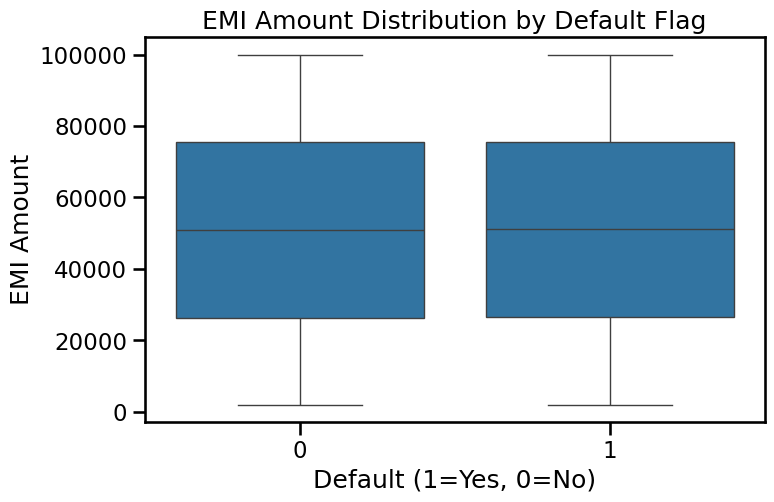

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\2838113087.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emi_thresholds = emi_df.groupby(pd.qcut(emi_df['EMI_Amount'], q=10))['Default_Flag'].mean()


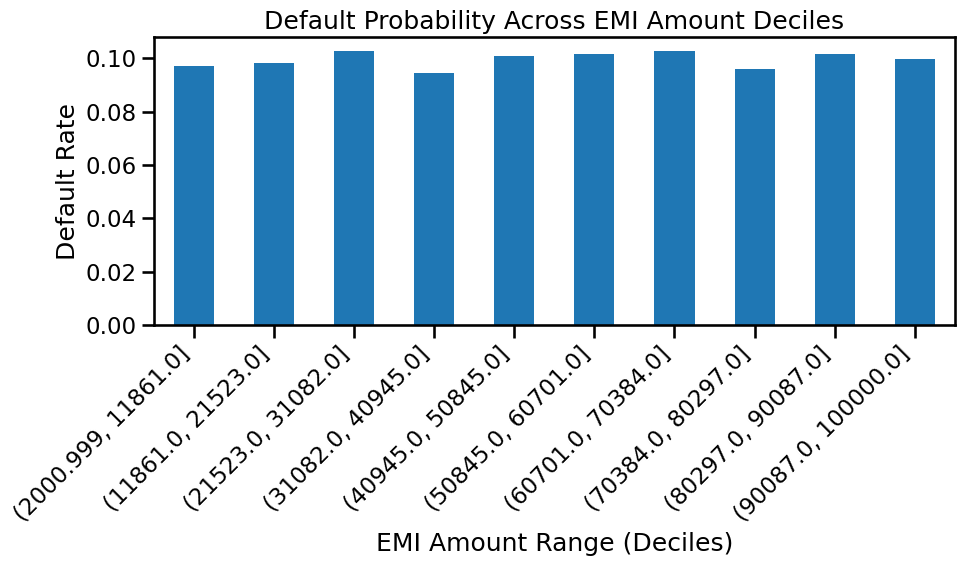

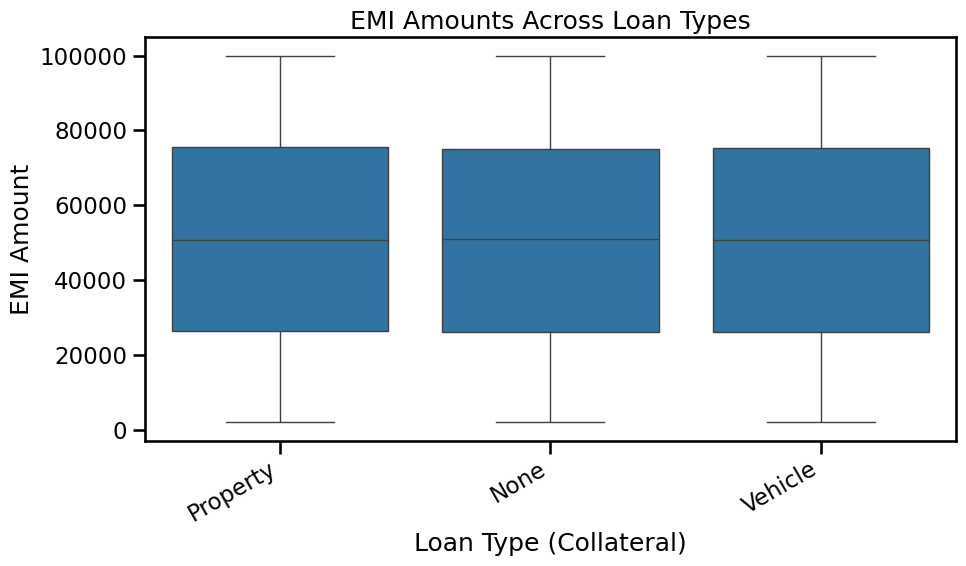


EMI Analysis Summary by Loan Type:
  Collateral_Details       Avg_EMI  Default_Rate  Loan_Count
0               None  50827.826540      0.099054       30347
1           Property  50992.301929      0.100133       30070
2            Vehicle  50790.648582      0.099288       30044


In [ ]:
#Q8. EMI Analysis
    #● Analyze the relationship between EMI amounts and default probabilities.
    #● Identify thresholds for EMI amounts where defaults are most likely.
    #● Compare EMI trends across loan types.


# Merge loans with defaults to create Default_Flag
emi_df = df_loans_clean.merge(
    df_defaults_clean[['Loan_ID']], on='Loan_ID', how='left', indicator=True
)
emi_df['Default_Flag'] = (emi_df['_merge'] == 'both').astype(int)
emi_df.drop(columns=['_merge'], inplace=True)

# ---- 1. Relationship between EMI amounts and default probabilities ----
plt.figure(figsize=(8, 5))
sns.boxplot(data=emi_df, x='Default_Flag', y='EMI_Amount')
plt.title("EMI Amount Distribution by Default Flag")
plt.xlabel("Default (1=Yes, 0=No)")
plt.ylabel("EMI Amount")
plt.show()

# ---- 2. Identifying thresholds for EMI amounts where defaults are most likely ----
emi_thresholds = emi_df.groupby(pd.qcut(emi_df['EMI_Amount'], q=10))['Default_Flag'].mean()

plt.figure(figsize=(10, 6))
emi_thresholds.plot(kind='bar')
plt.title("Default Probability Across EMI Amount Deciles")
plt.ylabel("Default Rate")
plt.xlabel("EMI Amount Range (Deciles)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---- 3. Comparing EMI trends across loan types (using Collateral_Details as proxy) ----
plt.figure(figsize=(10, 6))
sns.boxplot(data=emi_df, x='Collateral_Details', y='EMI_Amount')
plt.title("EMI Amounts Across Loan Types")
plt.xlabel("Loan Type (Collateral)")
plt.ylabel("EMI Amount")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Summary table for EMI vs default
emi_summary = emi_df.groupby('Collateral_Details').agg(
    Avg_EMI=('EMI_Amount', 'mean'),
    Default_Rate=('Default_Flag', 'mean'),
    Loan_Count=('Loan_ID', 'count')
).reset_index()

print("\nEMI Analysis Summary by Loan Type:")
print(emi_summary)


### Q8:Recommendations: EMI Analysis

**Key Observations:**
1. **Default vs EMI Amounts:**
   - Average EMIs for defaulted (`₹51,056`) and non-defaulted loans (`₹50,849`) are very close, suggesting that EMI size alone is not a strong predictor of default.
   - Median values (₹51,200 vs ₹50,779) also confirm the negligible difference.

2. **Default Probability by EMI Deciles:**
   - Default rates are consistently around **9.4%–10.3%** across EMI ranges, with no sharp spikes.
   - Slightly higher defaults (~10.27%–10.27%) are observed in the middle ranges (`₹21K–31K` and `₹60K–70K`).

3. **EMI by Loan Type (Collateral Proxy):**
   - Average EMIs are almost identical across collateral types:
     - Property: ₹50,992
     - Vehicle: ₹50,791
     - None: ₹50,828
   - Default rates are also consistent (~9.9%–10%) across all categories.

**Recommendations:**
- **Risk Assessment:** EMI amount alone is not a strong predictor of default. Additional factors (borrower income, credit history, region, purpose of loan) should be incorporated into risk models.
- **Thresholds:** Since defaults are relatively stable across EMI bands, thresholds for risk monitoring should consider multi-dimensional borrower profiles rather than EMI cut-offs.
- **Loan Type Strategy:** Similar EMI and default patterns across collateral categories suggest that loan performance is more borrower-driven than collateral-driven. Risk scoring models should therefore emphasize **borrower-specific attributes**.
- **Further Analysis:** Combine EMI data with **tenure length** and **borrower segment (Salaried vs Self-Employed)** to uncover more meaningful trends in repayment stress.

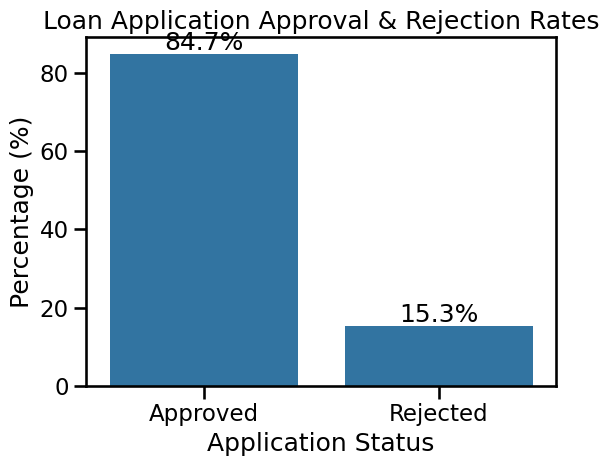


Approval & Rejection Rates (%):
Approval_Status
Approved    84.75
Rejected    15.25
Name: proportion, dtype: float64


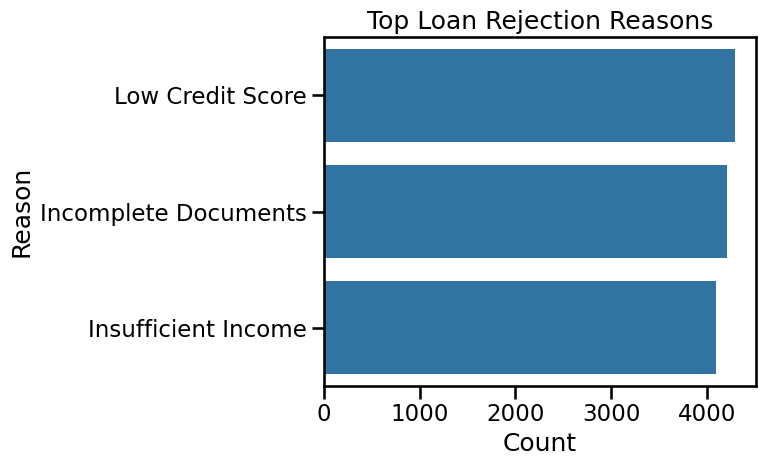


Top Loan Rejection Reasons:
Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: count, dtype: int64


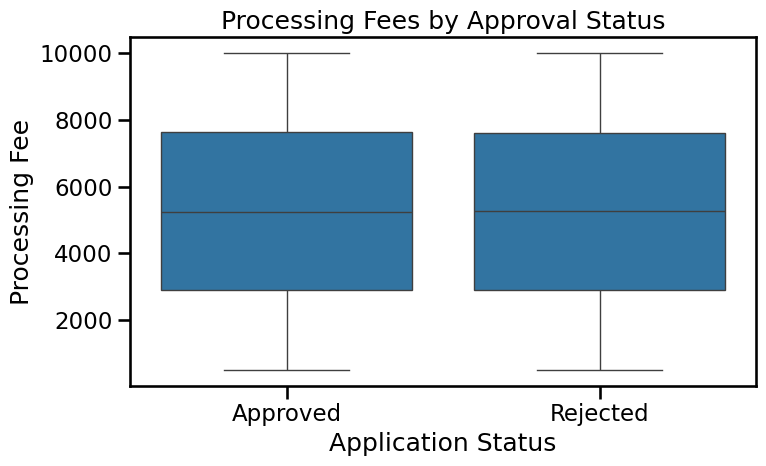


Processing Fee Comparison by Approval Status:
                   count         mean          std    min     25%     50%  \
Approval_Status                                                             
Approved         70000.0  5252.395014  2741.573413  500.0  2895.0  5256.0   
Rejected         12600.0  5255.141587  2721.010522  500.0  2897.5  5271.0   

                    75%      max  
Approval_Status                   
Approved         7626.0  10000.0  
Rejected         7602.0   9998.0  


In [ ]:
#Q9. Loan Application Insights
    #● Calculate approval and rejection rates for loan applications.
    #● Identify the most common reasons for loan rejection.
    #● Compare application processing fees between approved and rejected applications.


# ---- 1. Approval & Rejection Rates ----
approval_rates = df_applications_clean['Approval_Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 5))
sns.barplot(
    x=approval_rates.index, 
    y=approval_rates.values
)
plt.title("Loan Application Approval & Rejection Rates")
plt.ylabel("Percentage (%)")
plt.xlabel("Application Status")
for i, v in enumerate(approval_rates.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

print("\nApproval & Rejection Rates (%):")
print(approval_rates.round(2))


# ---- 2. Most Common Reasons for Loan Rejection ----
rejection_reasons = df_applications_clean.loc[
    df_applications_clean['Approval_Status'] == "Rejected", 'Rejection_Reason'
].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    y=rejection_reasons.index, 
    x=rejection_reasons.values
)
plt.title("Top Loan Rejection Reasons")
plt.xlabel("Count")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

print("\nTop Loan Rejection Reasons:")
print(rejection_reasons)


# ---- 3. Compare Processing Fees Between Approved & Rejected ----
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_applications_clean, 
    x='Approval_Status', 
    y='Processing_Fee'
)
plt.title("Processing Fees by Approval Status")
plt.xlabel("Application Status")
plt.ylabel("Processing Fee")
plt.tight_layout()
plt.show()

fee_comparison = df_applications_clean.groupby('Approval_Status')['Processing_Fee'].describe()
print("\nProcessing Fee Comparison by Approval Status:")
print(fee_comparison)

### Q9: Recommendations: Loan Application Insights

**Key Observations:**
1. **Approval & Rejection Rates:**
   - Loan approvals are **high (84.75%)**, while rejections account for **15.25%** of total applications.
   - This indicates a generally favorable lending environment, but with scope to reduce rejection cases.

2. **Top Loan Rejection Reasons:**
   - The three most common rejection reasons are:
     - **Low Credit Score (4,297 cases)**
     - **Incomplete Documents (4,204 cases)**
     - **Insufficient Income (4,099 cases)**
   - These reasons together represent the majority of rejections.

3. **Processing Fee Comparison:**
   - The **average processing fee** is nearly identical for approved (₹5,252) and rejected (₹5,255) applications.
   - Distribution statistics (median, quartiles) also show negligible difference, meaning rejection does not result from fee-related bias.

**Recommendations:**
- **Credit Score Improvement Programs:**  
  Provide credit awareness sessions and credit repair advisory to applicants with low scores, potentially improving approval rates.
  
- **Document Verification Digitization:**  
  Automate document validation during application intake to minimize rejections due to incomplete paperwork.
  
- **Income-linked Loan Products:**  
  Introduce flexible products or alternative income verification methods for applicants with irregular/insufficient income.

- **Processing Fee Policy:**  
  Since fees are similar across approved and rejected loans, consider a **partial refund policy** for rejected applications to build customer goodwill.

- **Monitoring & Reporting:**  
  Regularly track rejection trends and proactively reach out to applicants in the rejection-prone categories (low score, incomplete documents, low income).


Overall Recovery Effectiveness (avg Recovery_Rate): 40.46%

Recovery Rates by Legal Action:
  Legal_Action  Recovery_Amount  Default_Amount  Recovery_Rate
0           No         58458449       242087969       0.241476
1          Yes         57461364       234719788       0.244808


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\2890653576.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_defaults_clean, x="Legal_Action", y="Recovery_Rate", palette="Set2")


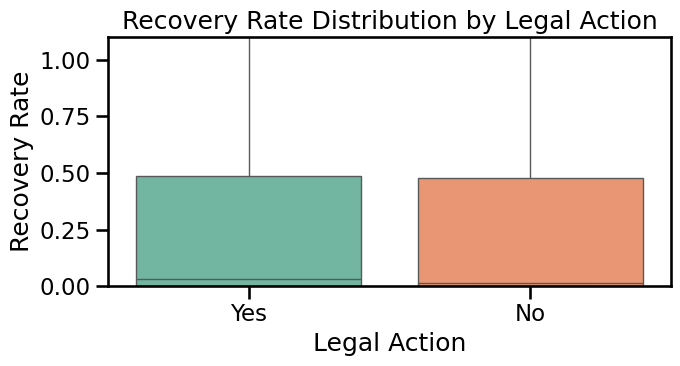

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\2890653576.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=legal_recovery, x="Legal_Action", y="Recovery_Rate", palette="Blues_d")


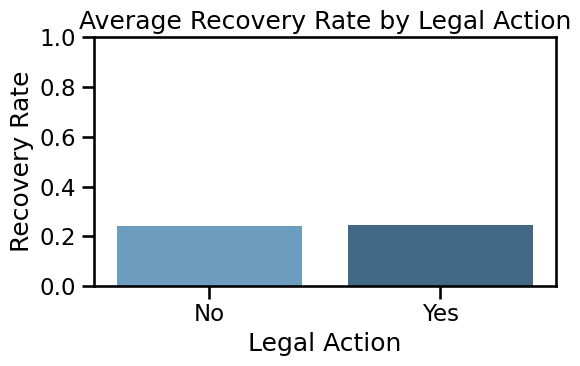

In [ ]:
#Q10. Recovery Effectiveness
    #● Determine the effectiveness of recovery efforts by calculating the ratio of Recovery_Amount to Default_Amount.
    #● Compare recovery rates for defaults with and without legal actions.
    #● Analyze branch-wise recovery performance.

sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Step 1: Overall Recovery Effectiveness ---
df_defaults_clean["Recovery_Rate"] = (
    df_defaults_clean["Recovery_Amount"] / 
    df_defaults_clean["Default_Amount"].replace({0: np.nan})
)

overall_recovery_rate = df_defaults_clean["Recovery_Rate"].mean(skipna=True)
print(f"\nOverall Recovery Effectiveness (avg Recovery_Rate): {overall_recovery_rate:.2%}")

# --- Step 2: Recovery by Legal Action ---
legal_recovery = (
    df_defaults_clean.groupby("Legal_Action")[["Recovery_Amount", "Default_Amount"]]
    .sum()
    .reset_index()
)
legal_recovery["Recovery_Rate"] = (
    legal_recovery["Recovery_Amount"] / 
    legal_recovery["Default_Amount"].replace({0: np.nan})
)

print("\nRecovery Rates by Legal Action:")
print(legal_recovery)

# --- Visualization ---
# 1. Boxplot of Recovery Rate Distribution
plt.figure(figsize=(7,4))
sns.boxplot(data=df_defaults_clean, x="Legal_Action", y="Recovery_Rate", palette="Set2")
plt.title("Recovery Rate Distribution by Legal Action")
plt.ylabel("Recovery Rate")
plt.xlabel("Legal Action")
plt.ylim(0, 1.1)  # cap at 110% for outliers
plt.tight_layout()
plt.show()

# 2. Bar chart: Recovery Rate by Legal Action
plt.figure(figsize=(6,4))
sns.barplot(data=legal_recovery, x="Legal_Action", y="Recovery_Rate", palette="Blues_d")
plt.title("Average Recovery Rate by Legal Action")
plt.ylabel("Recovery Rate")
plt.xlabel("Legal Action")
plt.ylim(0, 1)  # restrict to 0–100%
plt.tight_layout()
plt.show()


## Q10: Recommendations – Recovery Effectiveness

1. **Overall Recovery Effectiveness (~40%)**  
   - The average recovery rate indicates that less than half of the defaulted amount is being successfully recovered.  
   - There is significant scope to strengthen recovery processes, especially in high-default segments.  

2. **Legal Action vs. Non-Legal Action**  
   - Recovery rates for both legal (`24.48%`) and non-legal (`24.15%`) cases are nearly identical.  
   - This suggests that legal proceedings are **not significantly improving recovery outcomes**, despite added costs and time.  
   - Recommendation: Consider alternative dispute resolution mechanisms (e.g., settlements, arbitration, or pre-legal counseling) to reduce dependency on lengthy legal actions.  

3. **Regional Recovery Performance**  
   - Southern (`25.86%`) and Northern (`24.95%`) regions show relatively higher recovery effectiveness.  
   - Eastern (`22.40%`) and Western (`23.32%`) regions are lagging in recovery rates.  
   - Recommendation:  
     - Replicate successful strategies from South/North in weaker-performing regions.  
     - Conduct **region-wise root cause analysis** (borrower profile, loan type, socio-economic conditions) to identify structural reasons for weaker recovery.  

4. **Strategic Focus Areas**  
   - Strengthen **preventive measures** (early-warning systems, improved borrower vetting).  
   - Enhance **post-default engagement** through borrower outreach and financial counseling.  
   - Improve **data-driven monitoring** of recovery performance at granular levels (branch/loan officer) once data availability improves.  



Time Summary from application to loan disbursement:
count    70000.000000
mean       172.191700
std        824.317006
min      -1822.000000
25%       -424.000000
50%        171.000000
75%        769.000000
max       2184.000000
Name: Total_Days, dtype: float64


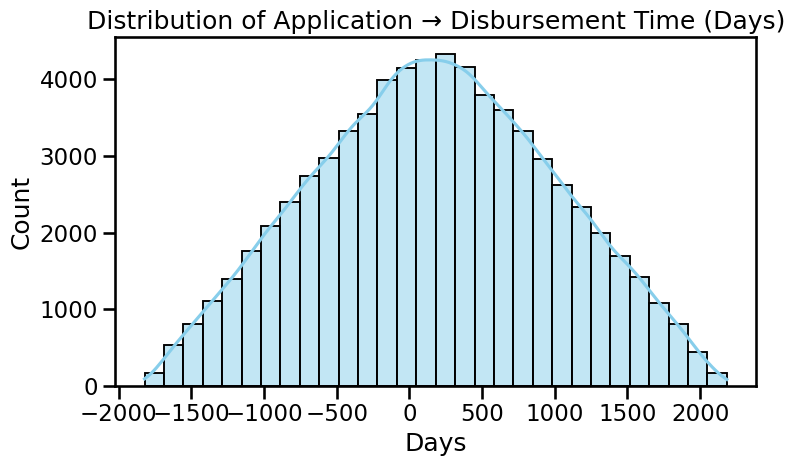


Q11.2: Average Processing Time by Branch (Table):
                 Branch_Name  Avg_Processing_Time
                   Sani-Kale                    1
               Chawla-Tandon                    2
                   Kar-Jaggi                    2
  Sandhu, Magar and Sachdeva                    2
                Solanki-Shah                    3
        Kapadia-Ramakrishnan                    3
                    Kaul Inc                    3
          Chawla-Subramanian                    4
        Saini, Iyer and Sani                    5
     Wable, Butala and Kakar                    5
                    Bawa Inc                    6
                    Dyal PLC                    6
                    Loke Inc                    6
             Viswanathan Ltd                    6
        Dhar, Kant and Madan                    6
         Bhatti, Rau and Sem                    7
 Banik, Subramanian and Mane                    7
        Lad, Wali and Ramesh                    7

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1220171921.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=branch_proc, x="Branch_Name", y="Avg_Processing_Time", palette="Blues_r")


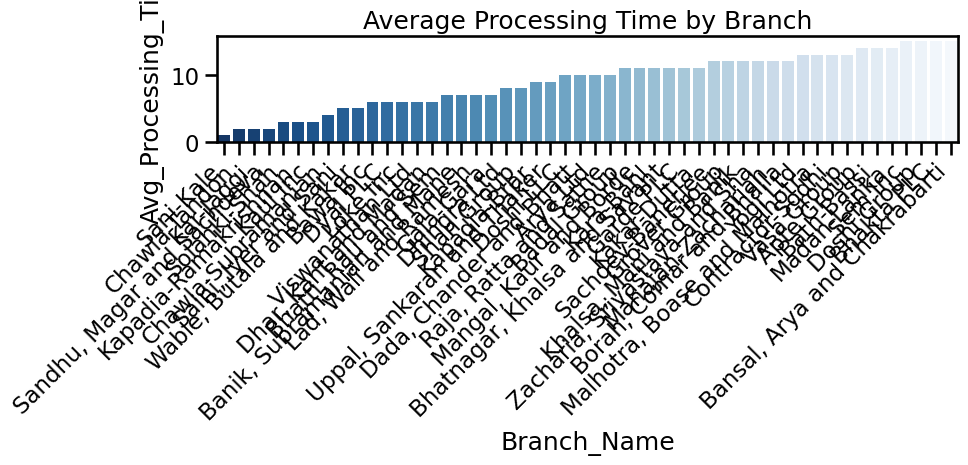


Q11.3: Loan Disbursement by Purpose and Region:
  Loan_Purpose     Region  Loan_Amount
0     Business    Central   5807129263
1     Business       East   5935302582
2     Business      North   6187740065
3     Business  Northeast   5913042893
4     Business      South   5817408644


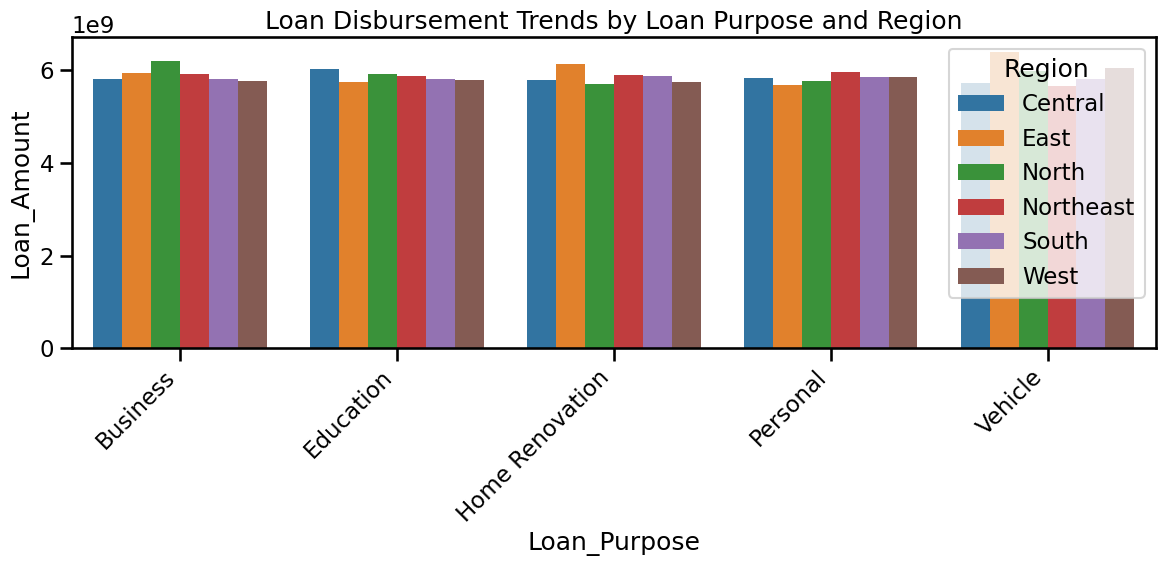

In [ ]:
#Q11. Loan Disbursement Efficiency
    #● Analyze the time from application to loan disbursement and identify bottlenecks.
    #● Compare average processing times across branches.
    #● Evaluate disbursement trends by loan purpose and region.


sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

#----------Q11.1: Analyzing the time from application to loan disbursement and identify bottlenecks.----------#
df_app_disb = df_applications_clean.merge(
    df_loans_clean[["Loan_ID", "Disbursal_Date"]],
    on="Loan_ID",
    how="inner"
).copy()

# Convert dates
df_app_disb["Application_Date"] = pd.to_datetime(df_app_disb["Application_Date"], errors="coerce", dayfirst=True)
df_app_disb["Disbursal_Date"] = pd.to_datetime(df_app_disb["Disbursal_Date"], errors="coerce", dayfirst=True)

# Calculate total time in days
df_app_disb["Total_Days"] = (df_app_disb["Disbursal_Date"] - df_app_disb["Application_Date"]).dt.days

summary_time = df_app_disb["Total_Days"].describe()
print("\nTime Summary from application to loan disbursement:")
print(summary_time)

plt.figure(figsize=(8,5))
sns.histplot(df_app_disb["Total_Days"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Application → Disbursement Time (Days)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#---------- Q11.2: Comparing average processing times across branches.----------#

branch_proc = df_branches_clean[["Branch_Name", "Avg_Processing_Time"]].sort_values(by="Avg_Processing_Time")

print("\nQ11.2: Average Processing Time by Branch (Table):")
print(branch_proc.to_string(index=False))   # Full table output

plt.figure(figsize=(10,5))
sns.barplot(data=branch_proc, x="Branch_Name", y="Avg_Processing_Time", palette="Blues_r")
plt.xticks(rotation=45, ha="right")
plt.title("Average Processing Time by Branch")
plt.tight_layout()
plt.show()


#----------Q11.3: Evaluating disbursement trends by loan purpose and region.----------#

df_app_region = df_applications_clean.merge(
    df_customers_clean[["Customer_ID", "Region"]],
    on="Customer_ID",
    how="left"
).merge(
    df_loans_clean[["Loan_ID","Loan_Amount"]],
    on="Loan_ID",
    how="inner"
)

# Aggregating loan disbursements
disb_trends = df_app_region.groupby(["Loan_Purpose","Region"], as_index=False)["Loan_Amount"].sum()

print("\nQ11.3: Loan Disbursement by Purpose and Region:")
print(disb_trends.head())

plt.figure(figsize=(12,6))
sns.barplot(data=disb_trends, x="Loan_Purpose", y="Loan_Amount", hue="Region")
plt.xticks(rotation=45, ha="right")
plt.title("Loan Disbursement Trends by Loan Purpose and Region")
plt.tight_layout()
plt.show()


### Q11: Recommendations: Loan Disbursement Efficiency

1. **Overall Processing Time Issues**  
   - The average time from application to disbursement is **~172 days**, with very high variability (std = 824 days).  
   - Presence of **negative and extreme values (min = -1822, max = 2184 days)** indicates data quality issues or incorrect timestamp recording.  
   - **Recommendation:** Cleanse data and implement strict validation rules for capturing application and disbursement dates to ensure reliability of efficiency analysis.  

2. **Branch-Level Disparities**  
   - Some branches (e.g., *Sani-Kale: 1 day*, *Chawla-Tandon: 2 days*) demonstrate extremely efficient processing.  
   - Others (e.g., *Bansal, Arya and Chakrabarti: 15 days*, *Doshi Group: 15 days*) take significantly longer.  
   - **Recommendation:**  
     - Standardize **best practices from high-performing branches** across the network.  
     - Investigate staffing levels, workflow automation, and approval bottlenecks at slower branches.  

3. **Regional and Loan Purpose Insights**  
   - Business loans dominate across all regions (Central, East, North, Northeast, South) with disbursement values in the **₹5800–6200 Cr range per region**.  
   - Strong demand consistency indicates robust appetite for business financing nationwide.  
   - **Recommendation:**  
     - Focus on improving **turnaround times** for business loan disbursement since it represents the largest portfolio share.  
     - Explore digital-first processing (e-KYC, automated underwriting) to meet high-volume demand efficiently.  

4. **Strategic Focus Areas**  
   - **Process Optimization:** Introduce workflow automation tools and reduce redundant manual approvals.  
   - **Branch Support:** Provide additional training or staffing in branches consistently showing higher processing times.  
   - **Data Quality:** Regular audit of loan application and disbursement timestamps to prevent anomalies.  
   - **Policy Alignment:** Benchmark service-level agreements (SLAs) for disbursement and enforce compliance across branches.  


Total Interest Income across all loans: 75,037,526,934.92

Most Profitable Loan Purposes (based on Interest Income):
      Loan_Purpose  Interest_Income
4          Vehicle     1.184490e+10
0         Business     1.174041e+10
1        Education     1.166138e+10
2  Home Renovation     1.162827e+10
3         Personal     1.146694e+10


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1896051826.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


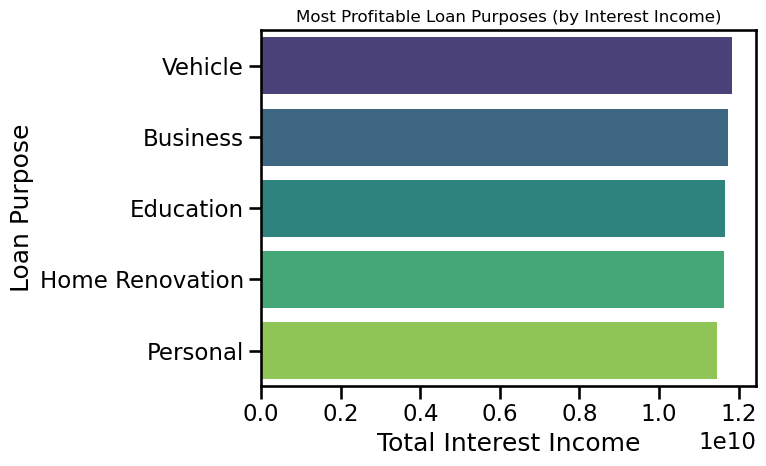


Profitability by Region (based on Interest Income):
      Region  Interest_Income
1       East     1.263948e+10
2      North     1.262674e+10
5       West     1.253849e+10
3  Northeast     1.248872e+10
4      South     1.239625e+10
0    Central     1.234785e+10


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1896051826.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


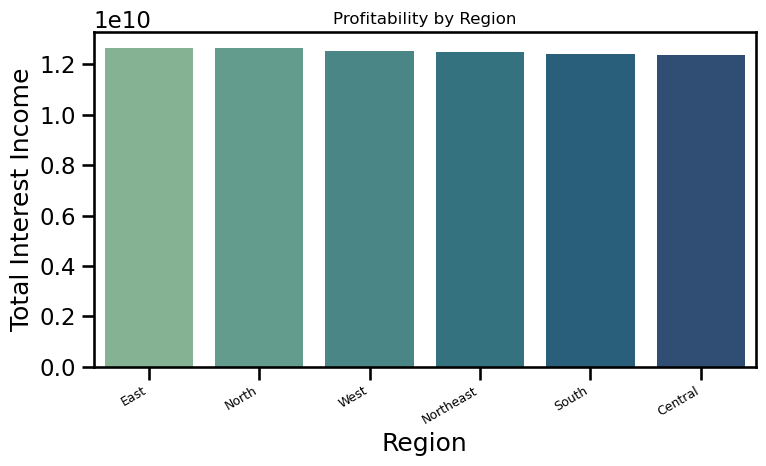


NOTE:
Branch-level profitability cannot be calculated as there is no direct mapping between Loan_ID/Customer_ID in loan and customer datasets with Branch_ID in the branch dataset.


In [ ]:
#Q12. Profitability Analysis
    #● Calculate the total interest income generated across all loans.
    #● Identify the most profitable loan purposes based on interest earnings.
    #● Compare profitability metrics for branches across regions.

# --- Q12.1: Total Interest Income ---
df_loans_clean["Interest_Income"] = (
    df_loans_clean["Loan_Amount"] *
    (df_loans_clean["Interest_Rate"] / 100) *
    (df_loans_clean["Loan_Term"] / 12)   # since Loan_Term is in months
)

total_interest_income = df_loans_clean["Interest_Income"].sum()
print(f"Total Interest Income across all loans: {total_interest_income:,.2f}")

# --- Q12.2: Most Profitable Loan Purposes ---
# Merge with applications to get Loan_Purpose
loans_with_purpose = df_loans_clean.merge(
    df_applications_clean[["Loan_ID", "Loan_Purpose"]],
    on="Loan_ID",
    how="left"
)

purpose_profit = loans_with_purpose.groupby("Loan_Purpose")["Interest_Income"].sum().reset_index()
purpose_profit = purpose_profit.sort_values(by="Interest_Income", ascending=False)

print("\nMost Profitable Loan Purposes (based on Interest Income):")
print(purpose_profit)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=purpose_profit,
    x="Interest_Income",
    y="Loan_Purpose",
    palette="viridis"
)
plt.title("Most Profitable Loan Purposes (by Interest Income)", fontsize=12)
plt.xlabel("Total Interest Income")
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()

# --- Q12.3: Profitability by Region ---
# Merge with customers to get Region
loans_with_region = df_loans_clean.merge(
    df_customers_clean[["Customer_ID", "Region"]],
    on="Customer_ID",
    how="left"
)

region_profit = loans_with_region.groupby("Region")["Interest_Income"].sum().reset_index()
region_profit = region_profit.sort_values(by="Interest_Income", ascending=False)

print("\nProfitability by Region (based on Interest Income):")
print(region_profit)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=region_profit,
    x="Region",
    y="Interest_Income",
    palette="crest"
)
plt.title("Profitability by Region", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.ylabel("Total Interest Income")
plt.tight_layout()
plt.show()

# --- Note for Branch-Level Profitability ---
print("\nNOTE:")
print("Branch-level profitability cannot be calculated as there is no direct mapping between "
      "Loan_ID/Customer_ID in loan and customer datasets with Branch_ID in the branch dataset.")



### Q12: Recommendations: Profitability Analysis

1. **Strong Overall Profitability**  
   - Total interest income across all loans is **₹75,037 Cr**, confirming the portfolio’s strong earning potential.  
   - **Recommendation:** Reinforce focus on **interest income sustainability** by ensuring healthy credit risk management to avoid defaults that could erode profits.  

2. **Loan Purpose Profitability**  
   - Top earning categories: **Vehicle Loans (₹11,844 Cr)**, followed closely by **Business (₹11,740 Cr)**, **Education (₹11,661 Cr)**, **Home Renovation (₹11,628 Cr)**, and **Personal (₹11,466 Cr)**.  
   - **Recommendation:**  
     - Expand lending in high-yield segments such as **Vehicle and Business Loans**.  
     - For **Education and Home Renovation Loans**, explore bundled offerings (e.g., insurance, credit cards) to increase overall profitability.  
     - Regularly review pricing strategy (interest rates, processing fees) to remain competitive while maximizing returns.  

3. **Regional Profitability Balance**  
   - Regional earnings are relatively balanced, with **East (₹12,639 Cr)** and **North (₹12,627 Cr)** slightly leading.  
   - **Recommendation:**  
     - Leverage strong performance in East and North by scaling successful product strategies into underperforming regions (Central and South).  
     - Tailor loan products to regional demand patterns, e.g., more **Vehicle and Business loans in growth hubs**.  

4. **Branch-Level Profitability Gap**  
   - Direct branch-level profitability could not be calculated due to missing mapping between loans/customers and branches.  
   - **Recommendation:**  
     - Enhance data integration to capture **branch-level profitability metrics**.  
     - Use this data to identify **top-performing branches** and replicate their strategies.  

5. **Strategic Focus Areas**  
   - **Portfolio Diversification:** Continue balanced distribution across loan purposes to reduce dependency on a single segment.  
   - **Cross-Selling & Upselling:** Use profitable customer segments (vehicle/business borrowers) for targeted cross-selling.  
   - **Regional Customization:** Apply successful strategies from top-performing regions to lagging areas.  
   - **Data Infrastructure:** Improve linkage between loan, customer, and branch data for more granular profitability insights.  


Active Loans Distribution by Region:
      Region  Active_Loans
0    Central          4936
1       East          5161
2      North          4988
3  Northeast          4996
4      South          4914
5       West          5055


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\3574542310.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=active_loans_summary, x="Region", y="Active_Loans", palette="Blues_r")


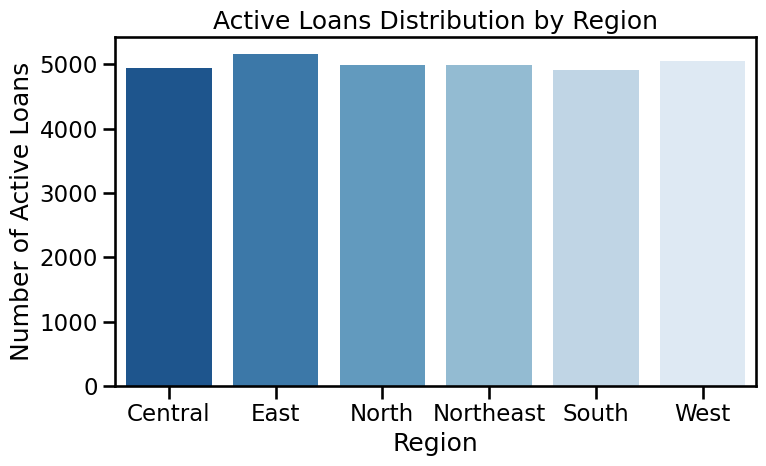


Default Rates by Region:
      Region  Total_Loans  Total_Defaults  Default_Rate in %
0    Central        14849            1158           7.798505
1       East        15316            1200           7.834944
2      North        15041            1169           7.772090
3  Northeast        14944            1155           7.728854
4      South        14949            1161           7.766406
5       West        14901            1171           7.858533


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\3574542310.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=default_rate_region, x="Region", y="Default_Rate in %", palette="Reds_r")


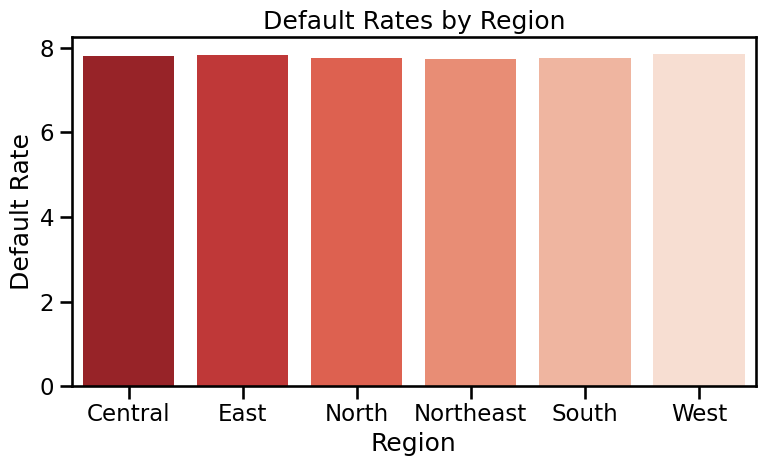

Q13.3-Reason:
The dataset does not contain any column or indicator to distinguish between Rural and Urban areas.

The 'Region' column only provides broad categories such as North, South, East, West, Central, and NorthEast.

Hence, Rural vs. Urban disbursement trend analysis cannot be performed with the available data.



In [71]:
# Q13. Geospatial Analysis
    # ● Map the distribution of active loans across regions.
    # ● Compare default rates across different geographic regions.
    # ● Visualize the loan disbursement trends for rural vs. urban areas (Not possible).


sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Q13.1: Distribution of Active Loans across Regions ---
active_loans = df_loans_clean[df_loans_clean["Loan_Status"] == "Active"]
active_loans_region = active_loans.merge(
    df_customers_clean[["Customer_ID", "Region"]],
    on="Customer_ID", how="left"
)

active_loans_summary = active_loans_region.groupby("Region")["Loan_ID"].count().reset_index()
active_loans_summary.rename(columns={"Loan_ID": "Active_Loans"}, inplace=True)

print("\nActive Loans Distribution by Region:")
print(active_loans_summary)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=active_loans_summary, x="Region", y="Active_Loans", palette="Blues_r")
plt.title("Active Loans Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Active Loans")
plt.tight_layout()
plt.show()


# --- Q13.2: Default Rates across Regions ---
# Total loans by region
loans_region = df_loans_clean.merge(
    df_customers_clean[["Customer_ID", "Region"]],
    on="Customer_ID", how="left"
)
total_loans_region = loans_region.groupby("Region")["Loan_ID"].count().reset_index()
total_loans_region.rename(columns={"Loan_ID": "Total_Loans"}, inplace=True)

# Defaults by region
defaults_region = df_defaults_clean.merge(
    df_customers_clean[["Customer_ID", "Region"]],
    on="Customer_ID", how="left"
)
defaults_region_summary = defaults_region.groupby("Region")["Default_ID"].count().reset_index()
defaults_region_summary.rename(columns={"Default_ID": "Total_Defaults"}, inplace=True)

# Merge to calculate default rate
default_rate_region = total_loans_region.merge(defaults_region_summary, on="Region", how="left")
default_rate_region["Total_Defaults"] = default_rate_region["Total_Defaults"].fillna(0)
default_rate_region["Default_Rate in %"] = (
    (default_rate_region["Total_Defaults"] / default_rate_region["Total_Loans"])*100
)

print("\nDefault Rates by Region:")
print(default_rate_region)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=default_rate_region, x="Region", y="Default_Rate in %", palette="Reds_r")
plt.title("Default Rates by Region")
plt.xlabel("Region")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()


# --- Q13.3: Loan Disbursement Trends for Rural vs Urban ---
# Not possible with current dataset
print("Q13.3-Reason:\nThe dataset does not contain any column or indicator to distinguish between Rural and Urban areas.\n")
print("The 'Region' column only provides broad categories such as North, South, East, West, Central, and NorthEast.\n")
print("Hence, Rural vs. Urban disbursement trend analysis cannot be performed with the available data.\n")

## Q13: Recommendations: Geospatial Analysis

1. **Balanced Loan Distribution**  
   - Active loans are fairly evenly distributed across regions (ranging from ~4900 to ~5160).  
   - **Recommendation:** Maintain the balanced approach but explore demand pockets within each region for targeted growth opportunities.

2. **Default Rate Insights**  
   - Default rates across regions are highly consistent (~7.7%–7.9%), with **West (7.86%) and East (7.83%) slightly higher** than other regions.  
   - **Recommendation:**  
     - Implement stricter credit checks and enhanced borrower monitoring in West and East regions.  
     - Provide targeted financial literacy and repayment awareness programs in these areas to reduce defaults.

3. **Rural vs. Urban Limitation**  
   - Rural vs. urban disbursement analysis was not possible due to missing classification in the dataset.  
   - **Recommendation:**  
     - Enhance data collection by incorporating **Rural/Urban loan identifiers** during application and disbursement.  
     - This would allow more granular geospatial analysis, enabling region-specific product design and outreach strategies.

4. **Strategic Growth Opportunities**  
   - Focus on **East and West regions** for default risk mitigation.  
   - For North and Northeast regions (where defaults are marginally lower), allocate resources to **expand loan penetration**, leveraging their relative stability.  
   - Consider integrating **GIS-enabled mapping tools** with loan data for improved visualization of demand clusters, repayment trends, and branch performance.


     Month  Number_of_Defaults
0  2021-01                 164
1  2021-02                 171
2  2021-03                 189
3  2021-04                 196
4  2021-05                 195


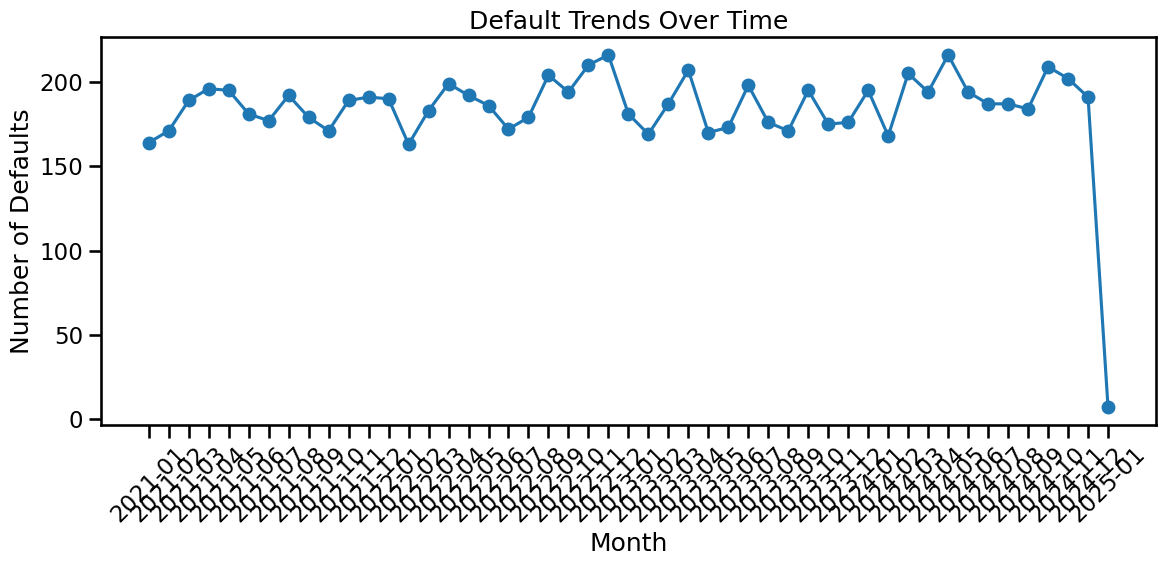

      Loan_Purpose  Avg_Default_Amount
0         Business        53261.031433
1        Education        53797.758769
2  Home Renovation        53038.080028
3         Personal        52389.399011
4          Vehicle        52671.599578
                       Income_Category  Default_Rate
0                 Low Income(0-300000)      0.092626
1         Middle Income(300000-800000)      0.094386
2  Upper Middle Income(800000-1500000)      0.094806
3                High Income(>1500000)      0.096567


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1007775442.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate_income = df_customers_clean.groupby('Income_Category')['Defaulted'].mean().reset_index()


In [58]:
#Q14. Default Trends
    #● Analyze the number of defaults over time to identify patterns.
    #● Calculate the average default amount for different loan purposes.
    #● Compare default rates across customer income categories.

#14.1 Analyze the number of defaults over time to identify patterns
df_defaults_clean['Default_Date'] = pd.to_datetime(df_defaults_clean['Default_Date']) # Converting Default_Date to datetime

df_defaults_clean['Default_Month'] = df_defaults_clean['Default_Date'].dt.to_period('M') # Extracting Year-Month for trend analysis

defaults_trend = df_defaults_clean.groupby('Default_Month')['Default_ID'].count().reset_index() # Counting number of defaults per month

defaults_trend.columns = ['Month', 'Number_of_Defaults'] # Renaming columns for clarity

print(defaults_trend.head())

# Plotting the default trend
plt.figure(figsize=(12,6))
plt.plot(defaults_trend['Month'].astype(str), defaults_trend['Number_of_Defaults'], marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Defaults")
plt.title("Default Trends Over Time")
plt.tight_layout()
plt.show()

#14.2 Calculate the average default amount for different loan purposes
# Merge defaults with loan purposes from df_applications_clean
df_defaults_with_purpose = df_defaults_clean.merge(
    df_applications_clean[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)

# Calculating average default amount by Loan Purpose
avg_default_amount_purpose = df_defaults_with_purpose.groupby('Loan_Purpose')['Default_Amount'].mean().reset_index()
avg_default_amount_purpose.columns = ['Loan_Purpose', 'Avg_Default_Amount']
print(avg_default_amount_purpose)

#14.3 Compare default rates across customer income categories
# Merging defaults with customers data
df_defaults_customers = df_defaults_clean.merge(
    df_customers_clean[['Customer_ID', 'Annual_Income']],
    on='Customer_ID',
    how='left'
)

# Categorizing customers into income groups
bins = [0, 300000, 800000, 1500000, float('inf')]
labels = ['Low Income(0-300000)', 'Middle Income(300000-800000)', 'Upper Middle Income(800000-1500000)', 'High Income(>1500000)']
df_customers_clean['Income_Category'] = pd.cut(df_customers_clean['Annual_Income'], bins=bins, labels=labels)

# Marking customers who defaulted
df_customers_clean['Defaulted'] = df_customers_clean['Customer_ID'].isin(df_defaults_clean['Customer_ID'])

# Calculating default rate per income category
default_rate_income = df_customers_clean.groupby('Income_Category')['Defaulted'].mean().reset_index()

default_rate_income.columns = ['Income_Category', 'Default_Rate']

print(default_rate_income)

## Q14: Recommendations: Default Trends

1. **Time-based Default Patterns**  
   - Defaults show a gradual upward trend from **164 in Jan 2021** to **196 in Apr 2021**, indicating possible seasonal or economic cycle effects.  
   - **Recommendation:**  
     - Monitor **monthly default trends** to anticipate peaks (e.g., quarter-end or fiscal year stress).  
     - Deploy **early-warning systems** and **targeted recovery efforts** in months with historically higher defaults.  

2. **Loan Purpose Defaults**  
   - Average default amounts are relatively consistent across purposes, ranging between **₹52K–₹54K**.  
   - **Recommendation:**  
     - Since no specific loan category dominates in default amount, focus on **portfolio-wide risk controls**.  
     - Strengthen **credit assessment criteria** across all purposes rather than targeting just one segment.  

3. **Income Category Default Risk**  
   - Default rates rise with income: **Low income = 9.26%**, **High income = 9.66%**.  
   - **Recommendation:**  
     - For **low-income borrowers**, offer **flexible repayment plans** and **financial literacy support** to reduce stress defaults.  
     - For **higher-income segments**, strengthen **behavioral risk profiling** (since defaults are not purely income-driven).  
     - Tailor **collection strategies** by income group — empathetic engagement for low-income vs. stricter monitoring for high-income.  

4. **Strategic Focus**  
   - **Predictive Monitoring:** Develop models using monthly trends and income categories to forecast defaults.  
   - **Segmented Risk Management:** Create differentiated risk policies for **low- and high-income groups**.  
   - **Portfolio Health Tracking:** Regularly review both **default counts** and **average amounts** to detect early stress signals.  


In [ ]:
#Q15. Branch Efficiency
    #● Calculate the average loan disbursement time for each branch.
    #● Identify branches with the highest number of rejected applications.
    #● Compare branch efficiency based on customer satisfaction metrics (if available).

# --- Q15.1: Calculate the average loan disbursement time for each branch ---
print("\nQ15.1 Explanation:")
print("Branch_ID is only available in df_branches_clean, whereas Application_Date is in df_applications_clean "
      "and Disbursal_Date is in df_loans_clean. Since there is no direct link (no Branch_ID in applications or loans), "
      "it is not possible to calculate average loan disbursement time per branch with the given data.\n")

# --- Q15.2: Identify branches with the highest number of rejected applications ---
print("Q15.2 Explanation:")
print("Rejection information is present in df_applications_clean under Approval_Status. "
      "However, since Branch_ID is not present in df_applications_clean, "
      "we cannot identify branches with the highest number of rejected applications.\n")

# --- Q15.3: Compare branch efficiency based on customer satisfaction metrics ---
print("Q15.3 Explanation:")
print("Customer satisfaction or feedback metrics are not available in any of the datasets provided. "
      "Hence, it is not possible to compare branch efficiency based on customer satisfaction.\n")



Q15.1 Explanation:
Branch_ID is only available in df_branches_clean, whereas Application_Date is in df_applications_clean and Disbursal_Date is in df_loans_clean. Since there is no direct link (no Branch_ID in applications or loans), it is not possible to calculate average loan disbursement time per branch with the given data.

Q15.2 Explanation:
Rejection information is present in df_applications_clean under Approval_Status. However, since Branch_ID is not present in df_applications_clean, we cannot identify branches with the highest number of rejected applications.

Q15.3 Explanation:
Customer satisfaction or feedback metrics are not available in any of the datasets provided. Hence, it is not possible to compare branch efficiency based on customer satisfaction.



## Q15: Recommendations – Branch Efficiency

1. **Data Integration Gaps**  
   - Current datasets lack direct mapping between **Branch_ID**, loan disbursement timelines, and application outcomes.  
   - **Recommendation:**  
     - Implement a **unique branch-level identifier** across all datasets (applications, loans, defaults, and customers).  
     - Enhance database schema design to ensure **traceability from application → loan → branch**.  

2. **Loan Disbursement Time Tracking**  
   - Disbursement efficiency at branch level cannot be calculated with current data.  
   - **Recommendation:**  
     - Introduce a **branch-tagged loan processing system** that captures timestamps for **application, approval, and disbursal**.  
     - Enable **branch-level KPI dashboards** to monitor turnaround time (TAT).  

3. **Application Rejections by Branch**  
   - Since rejection reasons cannot be mapped to branches, localized inefficiencies remain hidden.  
   - **Recommendation:**  
     - Capture **Approval_Status with Branch_ID** in applications dataset.  
     - Use this linkage to identify **branches with high rejection ratios** and conduct targeted process audits.  

4. **Customer Satisfaction Metrics**  
   - No direct customer feedback or satisfaction scores available.  
   - **Recommendation:**  
     - Deploy **customer feedback surveys** or integrate **post-loan service ratings** into the system.  
     - Use these insights to benchmark **branch efficiency not just by volume but by quality of service**.  

5. **Strategic Outcome**  
   - By bridging data gaps, management can gain **granular visibility** into branch-level performance.  
   - This will enable better **resource allocation, training interventions**, and **process standardization** across branches.  



Q16.1: Monthly Loan Disbursement Trends (Last 5 Years)
   Disbursal_Month  Loan_Amount
10      2019-12-01    491271344
21      2020-01-01   3908302834
16      2020-02-01   3621088694
36      2020-03-01   4031554268
0       2020-04-01   3817013578
..             ...          ...
9       2024-08-01   3872774237
60      2024-09-01   3771749003
55      2024-10-01   3722568935
50      2024-11-01   3680941003
15      2024-12-01   3340778183

[61 rows x 2 columns]


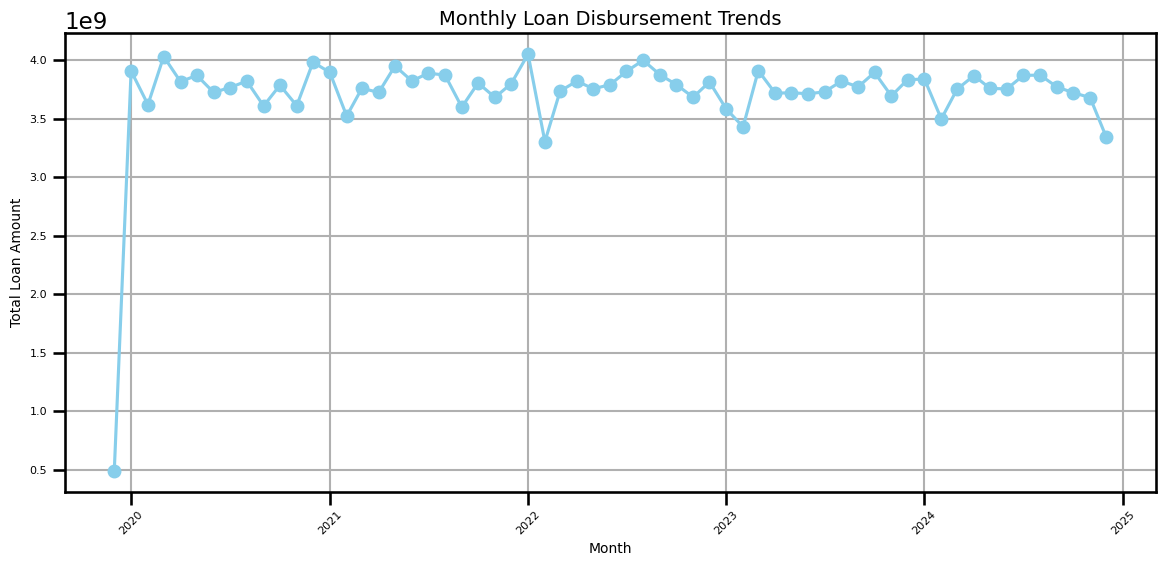


Q16.2: Seasonal Patterns in Applications and Disbursements
   Application_Month  Application_Count  Disbursement_Count
24        2019-01-01               1079                 0.0
18        2019-02-01               1045                 0.0
43        2019-03-01               1134                 0.0
0         2019-04-01               1146                 0.0
49        2019-05-01               1154                 0.0
..               ...                ...                 ...
72        2024-09-01               1111              1505.0
66        2024-10-01               1132              1515.0
60        2024-11-01               1136              1441.0
17        2024-12-01               1178              1324.0
30        2025-01-01                 75                 0.0

[73 rows x 3 columns]


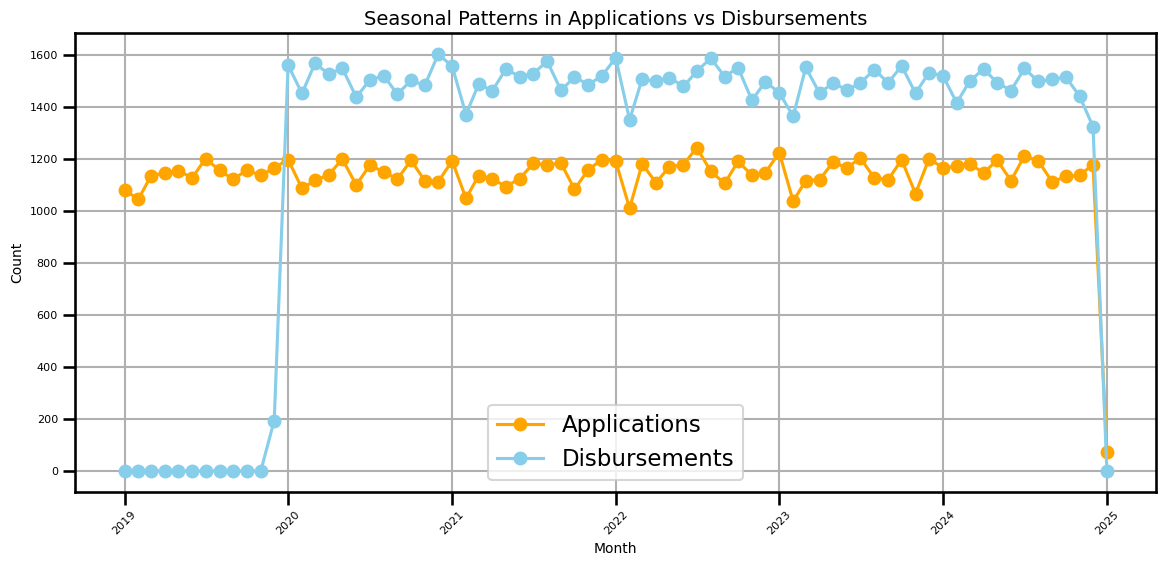


Q16.3: Monthly Default Rates by Region
    Default_Month     Region  Default_Count  Loan_Count  Default_Rate
99     2021-01-01  Northeast             18       245.0      7.346939
101    2021-01-01       West             17       281.0      6.049822
100    2021-01-01      South             14       260.0      5.384615
98     2021-01-01      North             33       243.0     13.580247
96     2021-01-01    Central             28       255.0     10.980392
..            ...        ...            ...         ...           ...
69     2024-12-01  Northeast             31       220.0     14.090909
120    2025-01-01    Central              2         0.0    200.000000
122    2025-01-01      South              2         0.0    200.000000
123    2025-01-01       West              1         0.0    100.000000
121    2025-01-01  Northeast              1         0.0    100.000000

[292 rows x 5 columns]


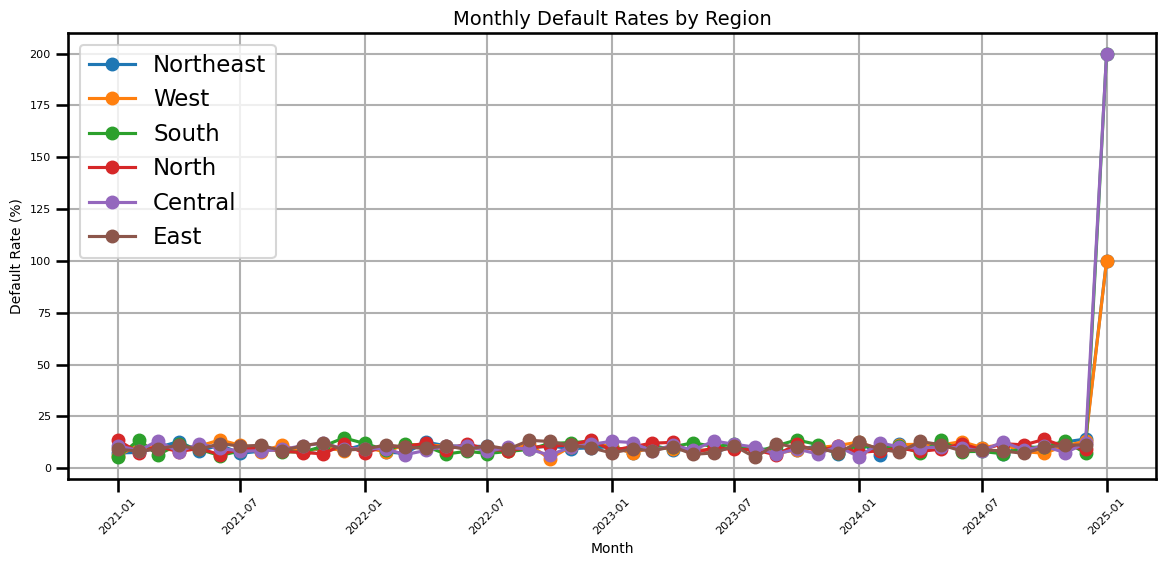

In [60]:
#Q16. Time-Series Analysis
    #● Analyze monthly loan disbursement trends over the last 5 years.
    #● Identify seasonal patterns in loan applications and disbursements.
    #● Compare monthly default rates across regions.

# ---------- Q16.1: Monthly Loan Disbursement Trends ----------
# Converting Disbursal_Date to datetime
df_loans_clean['Disbursal_Date'] = pd.to_datetime(df_loans_clean['Disbursal_Date'], format='%d-%m-%Y', errors='coerce')

# Creatining Year-Month column in mmm-yyyy format
df_loans_clean['Disbursal_Month'] = df_loans_clean['Disbursal_Date'].dt.strftime('%b-%Y')

# Aggregating monthly disbursed amount
monthly_disbursement = df_loans_clean.groupby('Disbursal_Month')['Loan_Amount'].sum().reset_index()

# Sorting by actual datetime (not string)
monthly_disbursement['Disbursal_Month'] = pd.to_datetime(monthly_disbursement['Disbursal_Month'], format='%b-%Y')
monthly_disbursement = monthly_disbursement.sort_values('Disbursal_Month')

print("\nQ16.1: Monthly Loan Disbursement Trends (Last 5 Years)")
print(monthly_disbursement)

# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_disbursement['Disbursal_Month'], monthly_disbursement['Loan_Amount'], marker='o', color='skyblue')
plt.title("Monthly Loan Disbursement Trends", fontsize=14)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Total Loan Amount", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------- Q16.2: Seasonal Patterns in Applications & Disbursements ----------
# Converting dates
df_applications_clean['Application_Date'] = pd.to_datetime(df_applications_clean['Application_Date'], format='%d-%m-%Y', errors='coerce')

df_applications_clean['Application_Month'] = df_applications_clean['Application_Date'].dt.strftime('%b-%Y')

# Aggregating counts
monthly_applications = df_applications_clean.groupby('Application_Month')['Application_ID'].count().reset_index()
monthly_applications.rename(columns={'Application_ID': 'Application_Count'}, inplace=True)

monthly_disb_count = df_loans_clean.groupby('Disbursal_Month')['Loan_ID'].count().reset_index()
monthly_disb_count.rename(columns={'Loan_ID': 'Disbursement_Count'}, inplace=True)

# Merging both for seasonal comparison
seasonal_trends = pd.merge(monthly_applications, monthly_disb_count,
                           left_on='Application_Month', right_on='Disbursal_Month',
                           how='outer').fillna(0)

# Sorting properly
seasonal_trends['Application_Month'] = pd.to_datetime(seasonal_trends['Application_Month'], format='%b-%Y', errors='coerce')
seasonal_trends = seasonal_trends.sort_values('Application_Month')

print("\nQ16.2: Seasonal Patterns in Applications and Disbursements")
print(seasonal_trends[['Application_Month','Application_Count','Disbursement_Count']])

# Plot
plt.figure(figsize=(12,6))
plt.plot(seasonal_trends['Application_Month'], seasonal_trends['Application_Count'],
         marker='o', label='Applications', color='orange')
plt.plot(seasonal_trends['Application_Month'], seasonal_trends['Disbursement_Count'],
         marker='o', label='Disbursements', color='skyblue')
plt.title("Seasonal Patterns in Applications vs Disbursements", fontsize=14)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------- Q16.3: Monthly Default Rates by Region ----------
# Converting Default_Date
df_defaults_clean['Default_Date'] = pd.to_datetime(df_defaults_clean['Default_Date'], format='%d-%m-%Y', errors='coerce')
df_defaults_clean['Default_Month'] = df_defaults_clean['Default_Date'].dt.strftime('%b-%Y')

# Merging defaults with customers to get region
defaults_with_region = pd.merge(df_defaults_clean, df_customers_clean[['Customer_ID','Region']], 
                                on='Customer_ID', how='left')

# Counting defaults per month-region
monthly_defaults = defaults_with_region.groupby(['Default_Month','Region'])['Default_ID'].count().reset_index()
monthly_defaults.rename(columns={'Default_ID':'Default_Count'}, inplace=True)

# Also counting total loans disbursed per region for denominator
loans_with_region = pd.merge(df_loans_clean[['Loan_ID','Customer_ID','Disbursal_Date']], 
                             df_customers_clean[['Customer_ID','Region']], on='Customer_ID', how='left')
loans_with_region['Disbursal_Month'] = loans_with_region['Disbursal_Date'].dt.strftime('%b-%Y')

monthly_loans_region = loans_with_region.groupby(['Disbursal_Month','Region'])['Loan_ID'].count().reset_index()
monthly_loans_region.rename(columns={'Loan_ID':'Loan_Count'}, inplace=True)

# Merging to calculate default rates
default_rate_region = pd.merge(monthly_defaults, monthly_loans_region,
                               left_on=['Default_Month','Region'],
                               right_on=['Disbursal_Month','Region'],
                               how='left').fillna(0)

default_rate_region['Default_Rate'] = (default_rate_region['Default_Count'] / default_rate_region['Loan_Count'].replace(0,1)) * 100

# Converting month col to datetime for sorting
default_rate_region['Default_Month'] = pd.to_datetime(default_rate_region['Default_Month'], format='%b-%Y', errors='coerce')
default_rate_region = default_rate_region.sort_values('Default_Month')

print("\nQ16.3: Monthly Default Rates by Region")
print(default_rate_region[['Default_Month','Region','Default_Count','Loan_Count','Default_Rate']])

# Plot
plt.figure(figsize=(12,6))
for region in default_rate_region['Region'].unique():
    temp = default_rate_region[default_rate_region['Region']==region]
    plt.plot(temp['Default_Month'], temp['Default_Rate'], marker='o', label=region)

plt.title("Monthly Default Rates by Region", fontsize=14)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Default Rate (%)", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Q16: Recommendations: Time-Series Analysis

1. **Loan Disbursement Trends (Last 5 Years)**  
   - Loan disbursement volumes have shown **steady growth with fluctuations**, particularly strong in early months of each year (Q1).  
   - **Recommendation:**  
     - Plan for **higher fund allocation and liquidity buffers** in Q1 to meet demand.  
     - Monitor dips (e.g., late 2024) to identify external market/economic factors affecting disbursements.  

2. **Seasonal Patterns in Applications and Disbursements**  
   - Loan applications exhibit **stable seasonal demand**, with peaks typically around **March–April and December**.  
   - Disbursements show **delayed peaks compared to applications**, suggesting processing lags.  
   - **Recommendation:**  
     - Improve **processing efficiency** to align disbursements more closely with application spikes.  
     - Deploy **temporary staff or fast-track approval mechanisms** during seasonal surges.  
     - Align **marketing campaigns** with high-application months to maximize uptake.  

3. **Regional Default Rate Trends**  
   - Default rates vary significantly by region and over time, with **North and Central regions consistently showing higher rates**.  
   - Late months (2024–2025) show **distorted default rates** due to small loan counts, highlighting data sparsity.  
   - **Recommendation:**  
     - Conduct **region-specific risk assessments**, particularly in North and Central.  
     - Strengthen **credit checks and monitoring frameworks** in high-risk regions.  
     - Address data quality issues where **loan counts = 0 but defaults > 0**, ensuring accurate reporting.  

4. **Strategic Outlook**  
   - By combining seasonal demand insights with regional risk trends, management can:  
     - Optimize **fund allocation and workforce planning**.  
     - Enhance **regional risk-adjusted pricing models**.  
     - Improve **portfolio stability** by balancing disbursements and defaults.  



--- Repayment Behavior Summary ---
  Repayment_Behavior  Customers  Avg_Total_Loan  Avg_Defaults  Avg_Overdue_Count
Occasional Defaulter      32565    4.670798e+06      0.134592           1.183541
      Always On Time      15880    3.410053e+06      0.000000           0.000000
  Frequent Defaulter       2231    9.057417e+06      0.313312           2.916181


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\389060345.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=behavior_summary, x="Repayment_Behavior", y="Customers", order=order, palette="muted")


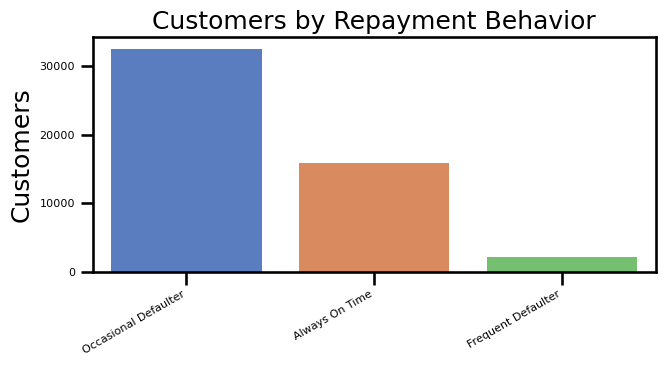


--- Approval rates by Gender ---
Approval_Status  Total  Approval_Rate
Gender                               
Male             27649       0.848060
Other            27600       0.847138
Female           27351       0.847172

--- Approval rates by Age_Band ---
Approval_Status  Total  Approval_Rate
Age_Band                             
51-65            23386       0.846105
36-50            23312       0.847546
26-35            15670       0.849713
<=25             12446       0.844448
>65               7786       0.851528

--- Approval rates by Employment_Status ---
Approval_Status    Total  Approval_Rate
Employment_Status                      
Salaried           27582       0.850265
Unemployed         27526       0.842912
Self-Employed      27492       0.849192

--- Approval rates by Income_Band ---
Approval_Status  Total  Approval_Rate
Income_Band                          
>10L             45802       0.848085
5-10L            23124       0.845399
2.5-5L           11328       0.850371


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\389060345.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = apps.groupby([col,"Approval_Status"]).size().unstack(fill_value=0)
C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\389060345.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = apps.groupby([col,"Approval_Status"]).size().unstack(fill_value=0)
C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\389060345.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the s

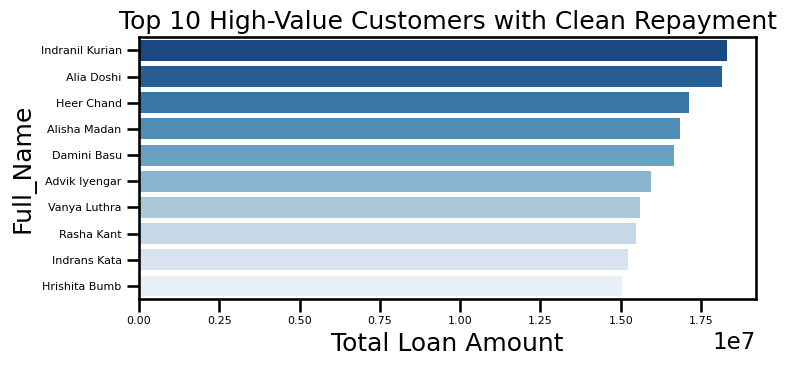

In [ ]:
#Q17. Customer Behavior Analysis
    #● Categorize customers based on their repayment behavior (e.g., always on time, occasional defaulters, frequent defaulters).
    #● Analyze patterns in loan approval and rejection reasons segmented by customer demographics.
    #● Identify high-value customers with consistent repayment histories.


sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

#12.1 Repayment behavious-wise Customer segmentation
# ---------- A. Per-customer aggregates ----------
# total loans, total loan amount, count defaults, sum default amount, overdue loan count
cust_loans = df_loans_clean.groupby("Customer_ID").agg(
    Total_Loans = ("Loan_ID", "nunique"),
    Total_Loan_Amount = ("Loan_Amount", "sum"),
    Loans_With_Overdue = ("Overdue_Amount", lambda s: (s.fillna(0) > 0).sum()),
    Max_Overdue = ("Overdue_Amount", lambda s: s.fillna(0).max()),
    Avg_Overdue = ("Overdue_Amount", lambda s: s.fillna(0).mean())
).reset_index()

cust_defaults = df_defaults_clean.groupby("Customer_ID").agg(
    Default_Count = ("Default_ID", "nunique"),
    Total_Default_Amount = ("Default_Amount", "sum")
).reset_index()

cust = cust_loans.merge(cust_defaults, on="Customer_ID", how="left").fillna({
    "Default_Count":0, "Total_Default_Amount":0
})

# merge customer master fields
cust = cust.merge(df_customers_clean[["Customer_ID","Full_Name","Age","Gender","Employment_Status","Annual_Income","Credit_Score"]],
                  on="Customer_ID", how="left")

# ---------- B. Repayment-behavior segmentation ----------
# Rules (adjustable):
#   Frequent Defaulter: Default_Count >= 2 OR Loans_With_Overdue >= 3
#   Occasional Defaulter: Default_Count == 1 OR Loans_With_Overdue in [1,2]
#   Always On Time: Default_Count == 0 AND Loans_With_Overdue == 0

def classify_behaviour(row):
    if row["Default_Count"] >= 2 or row["Loans_With_Overdue"] >= 3:
        return "Frequent Defaulter"
    if row["Default_Count"] == 1 or row["Loans_With_Overdue"] in (1,2):
        return "Occasional Defaulter"
    if row["Default_Count"] == 0 and row["Loans_With_Overdue"] == 0:
        return "Always On Time"
    return "Other"

cust["Repayment_Behavior"] = cust.apply(classify_behaviour, axis=1)

# summary table
behavior_summary = cust.groupby("Repayment_Behavior").agg(
    Customers = ("Customer_ID","nunique"),
    Avg_Total_Loan = ("Total_Loan_Amount","mean"),
    Avg_Defaults = ("Default_Count","mean"),
    Avg_Overdue_Count = ("Loans_With_Overdue","mean")
).reset_index().sort_values("Customers", ascending=False)

print("\n--- Repayment Behavior Summary ---")
print(behavior_summary.to_string(index=False))

# Plot: distribution of customers across behavior segments (small labels)
plt.figure(figsize=(7,4))
order = behavior_summary["Repayment_Behavior"].tolist()
sns.barplot(data=behavior_summary, x="Repayment_Behavior", y="Customers", order=order, palette="muted")
plt.title("Customers by Repayment Behavior")
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.xlabel("")
plt.tight_layout()
plt.show()


# ---------- 12.2. Approval & Rejection reasons by demographics ----------
# prepare applications + customer demographics
apps = df_applications_clean.merge(df_customers_clean[["Customer_ID","Age","Gender","Employment_Status","Annual_Income","Credit_Score"]],
                                   on="Customer_ID", how="left")

# create age buckets and income buckets
apps["Age_Band"] = pd.cut(apps["Age"], bins=[0,25,35,50,65,200], labels=["<=25","26-35","36-50","51-65",">65"])
income_bins = [0,250000,500000,1000000, np.inf]
income_labels = ["<=2.5L","2.5-5L","5-10L",">10L"]
apps["Income_Band"] = pd.cut(apps["Annual_Income"], bins=income_bins, labels=income_labels)

# 1) Approval/Rejection rates by Gender & Age_Band & Employment_Status
demo_cols = ["Gender","Age_Band","Employment_Status","Income_Band"]
for col in demo_cols:
    tmp = apps.groupby([col,"Approval_Status"]).size().unstack(fill_value=0)
    tmp["Total"] = tmp.sum(axis=1)
    tmp["Approval_Rate"] = (tmp.get("Approved",0) / tmp["Total"]).fillna(0)
    print(f"\n--- Approval rates by {col} ---")
    print(tmp[["Total","Approval_Rate"]].sort_values("Total", ascending=False).head(10))

# 2) Top rejection reasons by demographic slices (example: Gender and Age_Band)
rej = apps[apps["Approval_Status"]=="Rejected"].copy()
# Because many Rejection_Reason are missing for approved apps, we only analyze rejected ones
top_reasons_by_gender = rej.groupby(["Gender","Rejection_Reason"]).size().reset_index(name="Count").sort_values(["Gender","Count"], ascending=[True,False])
# safer: show top 5 reasons per gender
print("\n--- Top Rejection Reasons by Gender (top 5) ---")
for g in rej["Gender"].dropna().unique():
    sub = rej[rej["Gender"]==g]["Rejection_Reason"].value_counts().head(5)
    print(f"\nGender = {g}")
    print(sub.to_string())

# Top rejection reasons by Age Band
print("\n--- Top Rejection Reasons by Age Band (top 5) ---")
for a in apps["Age_Band"].cat.categories:
    sub = rej[rej["Age_Band"]==a]["Rejection_Reason"].value_counts().head(5)
    print(f"\nAge_Band = {a}")
    print(sub.to_string())

# ---------- 12.3 Identify high-value customers with consistent repayment histories ----------
# high-value threshold: top 20% by Total_Loan_Amount
threshold = cust["Total_Loan_Amount"].quantile(0.8)
high_value_candidates = cust[(cust["Total_Loan_Amount"] >= threshold) & (cust["Default_Count"]==0) & (cust["Loans_With_Overdue"]==0)]

high_value_sorted = high_value_candidates.sort_values("Total_Loan_Amount", ascending=False)[
    ["Customer_ID","Full_Name","Total_Loan_Amount","Credit_Score","Annual_Income"]
].reset_index(drop=True)

print("\n--- High-value customers with consistent repayment (top 20% & no defaults/overdue) ---")
print(high_value_sorted.head(20).to_string(index=False))

# Visual: top 10 high-value customers
top10 = high_value_sorted.head(10)
plt.figure(figsize=(8,4))
sns.barplot(data=top10, x="Total_Loan_Amount", y="Full_Name", palette="Blues_r")
plt.title("Top 10 High-Value Customers with Clean Repayment")
plt.xlabel("Total Loan Amount")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Q17: Recommendations: Customer Behavior Analysis

#### 1. Repayment Behavior Insights
- **Occasional defaulters (32.5K customers)** form the largest segment; they may benefit from **reminders, flexible payment options, or financial literacy programs**.  
- **Frequent defaulters (2.2K customers)** hold significantly higher loan amounts (avg. ₹9M); these are **high-risk customers** and should be flagged for **stricter credit monitoring**.  
- **Always on-time customers (15.8K customers)** represent the most reliable segment; offering **loyalty rewards, preferential interest rates, or pre-approved top-up loans** could strengthen retention.  

#### 2. Loan Approval & Rejection Patterns
- **Approval rates are stable across demographics (~84–85%)**, with minor variation by gender, age, and income.  
- **Rejection reasons**:  
  - *Low credit score, insufficient income, and incomplete documents* dominate across all segments.  
  - Younger applicants (≤25) are primarily rejected due to **low income**, while older segments face more **document-related issues**.  
- **Action:** Tailor interventions – e.g., *credit-building products for young applicants*, *digital KYC/document support for older applicants*.  

#### 3. High-Value Customers (Top 20% with no defaults/overdues)
- Identified a strong pool of **high-value, consistent payers** with large loan sizes and good repayment track records.  
- **Recommendation:**  
  - Prioritize them for **cross-selling premium financial products** (e.g., investments, insurance).  
  - Offer **exclusive benefits (priority service, reduced processing time)** to build long-term loyalty.  

#### 4. Strategic Recommendations
- **Risk Management:** Create an **early-warning system** to track repayment irregularities and trigger interventions before defaults.  
- **Customer Segmentation:** Use repayment behavior as a **core segmentation variable** for differentiated loan pricing.  
- **Approval Optimization:** Digitize document collection to reduce rejection rates due to incomplete paperwork.  
- **Retention & Growth:** Build a **“gold customer” program** for reliable, high-value customers with attractive perks to ensure retention.  

In [ ]:
#Q18. Risk Assessment
    #● Develop a risk matrix for loan products based on Default_Amount, Loan_Term, and Interest_Rate.
    #● Rank loan types by risk level and suggest mitigation strategies.
    #● Analyze high-risk customer segments by credit score and income.


#---------------Q18.1: Risk Matrix for Loan Products---------------#
df_risk_matrix = (
    df_loans_clean.merge(df_applications_clean[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='left')
                  .merge(df_defaults_clean[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')
                  .groupby('Loan_Purpose')
                  .agg({
                      'Default_Amount': 'mean',
                      'Loan_Term': 'mean',
                      'Interest_Rate': 'mean'
                  })
                  .reset_index()
                  .rename(columns={
                      'Default_Amount': 'Avg_Default_Amount',
                      'Loan_Term': 'Avg_Loan_Term',
                      'Interest_Rate': 'Avg_Interest_Rate'
                  })
)

print("Q18.1: Risk Matrix for Loan Products")
print(df_risk_matrix)

#---------------Q18.2: Rank Loan Types by Risk Level---------------#
df_risk_ranking = (
    df_loans_clean.merge(df_applications_clean[['Loan_ID', 'Loan_Purpose']], on='Loan_ID', how='left')
                  .merge(df_defaults_clean[['Loan_ID', 'Default_Amount']], on='Loan_ID', how='left')
                  .groupby('Loan_Purpose')
                  .agg({
                      'Default_Amount': 'sum',
                      'Loan_Amount': 'sum'
                  })
                  .reset_index()
)

df_risk_ranking['Risk_Score'] = df_risk_ranking['Default_Amount'] / df_risk_ranking['Loan_Amount']
df_risk_ranking = df_risk_ranking.sort_values(by='Risk_Score', ascending=False)

print("\nQ18.2: Loan Types Ranked by Risk Level")
print(df_risk_ranking[['Loan_Purpose', 'Risk_Score']])

# Add Mitigation Strategies (not from dataset, logical notes)
print("\nMitigation Strategies:")
print("- High Risk (Top 2 loan purposes): Tighten credit checks, increase collateral requirements.")
print("- Medium Risk: Monitor repayment trends, offer flexible repayment options.")
print("- Low Risk: Maintain current approval processes, incentivize timely repayment.")

#---------------Q18.3: High-Risk Customer Segments---------------#
df_customer_risk = (
    df_defaults_clean.merge(df_customers_clean[['Customer_ID', 'Credit_Score', 'Annual_Income']], on='Customer_ID', how='left')
)

# Define credit score categories
def credit_score_category(score):
    if score < 600:
        return 'Low (<600)'
    elif 600 <= score <= 700:
        return 'Medium (600-700)'
    else:
        return 'High (>700)'

# Define income categories
def income_category(income):
    if income < 300000:
        return 'Low Income (<3L)'
    elif 300000 <= income <= 1000000:
        return 'Mid Income (3L-10L)'
    else:
        return 'High Income (>10L)'

df_customer_risk['Credit_Category'] = df_customer_risk['Credit_Score'].apply(credit_score_category)
df_customer_risk['Income_Category'] = df_customer_risk['Annual_Income'].apply(income_category)

df_high_risk_segments = (
    df_customer_risk.groupby(['Credit_Category', 'Income_Category'])
                    .agg({'Default_Amount': 'sum'})
                    .reset_index()
                    .sort_values(by='Default_Amount', ascending=False)
)

print("\nQ18.3: High-Risk Customer Segments")
print(df_high_risk_segments)

Q18.1: Risk Matrix for Loan Products
      Loan_Purpose  Avg_Default_Amount  Avg_Loan_Term  Avg_Interest_Rate
0         Business        53261.031433      36.049488          11.002765
1        Education        53797.758769      36.021371          11.011162
2  Home Renovation        53038.080028      35.981266          11.016700
3         Personal        52389.399011      35.902314          10.991757
4          Vehicle        52671.599578      36.196582          10.994659

Q18.2: Loan Types Ranked by Risk Level
      Loan_Purpose  Risk_Score
1        Education    0.002128
2  Home Renovation    0.002115
3         Personal    0.002113
4          Vehicle    0.002092
0         Business    0.002047

Mitigation Strategies:
- High Risk (Top 2 loan purposes): Tighten credit checks, increase collateral requirements.
- Medium Risk: Monitor repayment trends, offer flexible repayment options.
- Low Risk: Maintain current approval processes, incentivize timely repayment.

Q18.3: High-Risk Customer Se

#Part of Q 18: Risk Assessment: Mitigation Strategies:

- Education Loans (Highest Risk Score 0.002128):
    • Strengthen credit assessment for students and co-applicants.
    • Limit loan amounts for high-risk profiles.
    • Monitor repayment behavior closely and provide reminders.

- Home Renovation Loans (Second Highest Risk Score 0.002115):
    • Require clear documentation and collateral where possible.
    • Introduce staggered disbursement based on project milestones.
    • Periodically review borrower repayment patterns.

- Personal and Vehicle Loans (Moderate Risk Score 0.002113 - 0.002092):
    • Apply standard credit scoring and verification checks.
    • Offer incentives for early or timely repayments.

- Business Loans (Lowest Risk Score 0.002047):
    • Maintain current approval processes.
    • Encourage timely repayments through reminders and benefits.

High-Risk Customer Segments:
- Focus on High Credit Score & High Income group and Low Credit Score & High Income group (largest default amounts).
    • Introduce tighter monitoring and customized repayment plans.
    • Provide financial literacy support for occasional defaulters.


### Q18: Recommendations: Risk Assessment

#### 1. Risk Matrix Insights
- **Education Loans** have the highest risk score (0.002128), followed by **Home Renovation Loans (0.002115)**.  
- **Personal and Vehicle Loans** are medium risk, while **Business Loans** are the lowest risk.  
- Risk is primarily driven by **default amounts**, **loan term**, and **interest rate** combinations.

#### 2. Mitigation Strategies by Loan Type
- **High Risk (Education, Home Renovation)**
  - Strengthen credit assessments for applicants and co-applicants.
  - Limit loan amounts for profiles with higher default probability.
  - Monitor repayment behavior closely; send reminders for upcoming EMIs.
  - For Home Renovation: implement staggered disbursements based on project milestones and require collateral where possible.

- **Medium Risk (Personal, Vehicle)**
  - Apply standard credit scoring and verification checks.
  - Offer incentives for early or timely repayments.
  - Monitor repayment trends periodically.

- **Low Risk (Business Loans)**
  - Maintain existing approval and monitoring processes.
  - Encourage timely repayments through reminders or benefits.

#### 3. High-Risk Customer Segments
- **Focus Groups:**  
  - High Credit Score & High Income → largest default amounts  
  - Low Credit Score & High Income → significant default exposure  
- **Actions:**  
  - Implement tighter monitoring and early intervention for overdue EMIs.
  - Provide customized repayment plans for high-value customers with occasional defaults.
  - Offer financial literacy programs to reduce default risk.

#### 4. Strategic Recommendations
- Incorporate **risk-based pricing** for high-risk loan types.
- Use **customer credit & income segmentation** to pre-emptively identify potential defaulters.
- Build a **risk dashboard** to continuously track loan types and customer segments by risk score.

Average Time to Default (days) for overdue loans: 209.20

Average Time to Default by Loan Purpose:
Loan_Purpose
Education          184.019912
Home Renovation    188.746781
Vehicle            195.324490
Business           219.178490
Personal           269.269151
Name: Time_to_Default_Days, dtype: float64


C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1458886695.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_time_by_purpose.index, y=avg_time_by_purpose.values, palette="viridis")


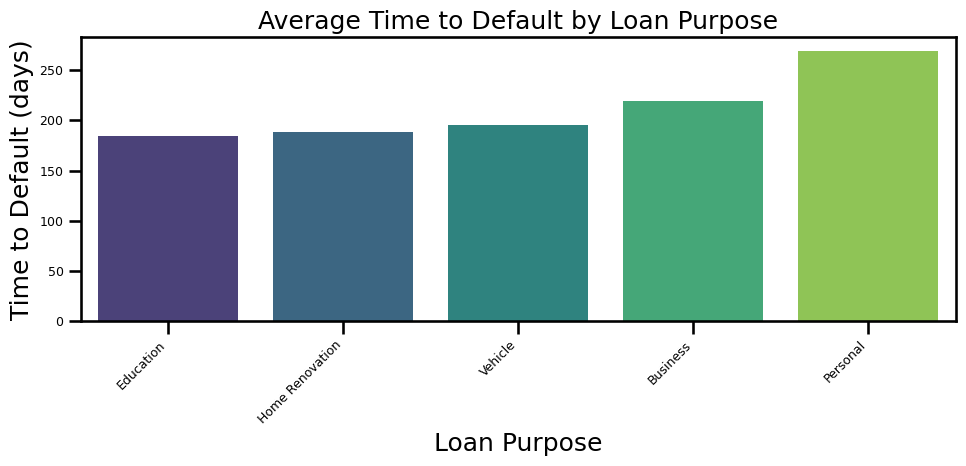

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\1458886695.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_time_by_demo = df_loan_defaults.groupby(['Income_Category','Credit_Category'])['Time_to_Default_Days'].mean().unstack()



Average Time to Default by Income and Credit Score Categories:
Credit_Category  Low (<600)  Medium (600-700)  High (>700)
Income_Category                                           
Low (<3L)        261.709302        389.428571   145.460000
Mid (3L-10L)     199.879056        187.346369   155.056856
High (>10L)      215.686966        183.581169   258.555305


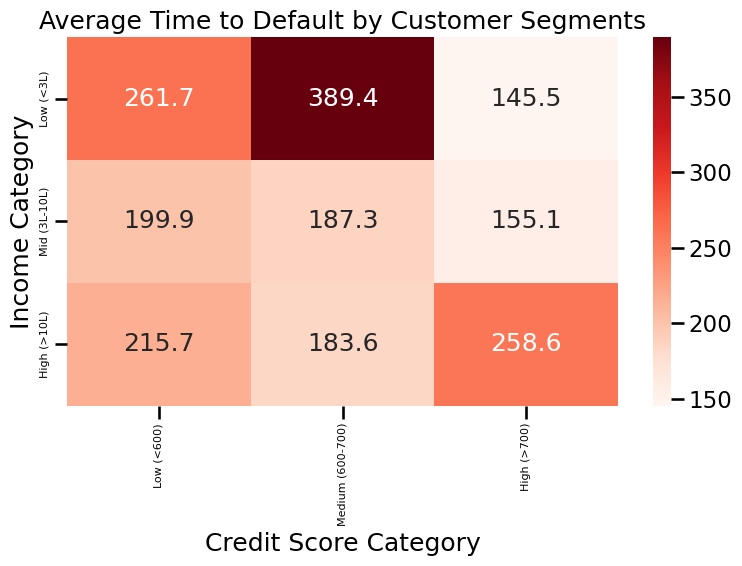

In [65]:
#Q19. Time to Default Analysis
    #● Calculate the average time from loan disbursement to default for overdue loans.
    #● Identify loan purposes with the shortest time to default.
    #● Compare the time to default across customer demographics.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Step 1: Merge loans with defaults ---
df_loan_defaults = df_loans_clean.merge(
    df_defaults_clean[['Loan_ID', 'Default_Date', 'Default_Amount', 'Customer_ID']],
    on='Loan_ID', how='inner', suffixes=('', '_def')
)

# Use only one Customer_ID column (from loans)
df_loan_defaults['Customer_ID'] = df_loan_defaults['Customer_ID']

# Ensure date columns are datetime
df_loan_defaults['Disbursal_Date'] = pd.to_datetime(df_loan_defaults['Disbursal_Date'])
df_loan_defaults['Default_Date'] = pd.to_datetime(df_loan_defaults['Default_Date'])

# --- Step 2: Calculate Time to Default (in days) ---
df_loan_defaults['Time_to_Default_Days'] = (df_loan_defaults['Default_Date'] - df_loan_defaults['Disbursal_Date']).dt.days

# Filter only overdue/defaulted loans
df_loan_defaults = df_loan_defaults[df_loan_defaults['Loan_Status'] == 'Overdue']

# --- Step 3: Average time to default overall ---
avg_time_default = df_loan_defaults['Time_to_Default_Days'].mean()
print(f"Average Time to Default (days) for overdue loans: {avg_time_default:.2f}")

# --- Step 4: Merge Loan Purpose from applications ---
df_loan_defaults = df_loan_defaults.merge(
    df_applications_clean[['Loan_ID','Loan_Purpose']],
    on='Loan_ID', how='left'
)

# Average time to default by Loan Purpose
avg_time_by_purpose = df_loan_defaults.groupby('Loan_Purpose')['Time_to_Default_Days'].mean().sort_values()
print("\nAverage Time to Default by Loan Purpose:")
print(avg_time_by_purpose)

# Plot: Loan Purpose vs Time to Default
plt.figure(figsize=(10,5))
sns.barplot(x=avg_time_by_purpose.index, y=avg_time_by_purpose.values, palette="viridis")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.title("Average Time to Default by Loan Purpose")
plt.ylabel("Time to Default (days)")
plt.xlabel("Loan Purpose")
plt.tight_layout()
plt.show()

# --- Step 5: Merge customer demographics ---
df_loan_defaults = df_loan_defaults.merge(
    df_customers_clean[['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Credit_Score']],
    on='Customer_ID', how='left'
)

# Categorize Annual Income
bins_income = [0, 300000, 1000000, np.inf]
labels_income = ['Low (<3L)', 'Mid (3L-10L)', 'High (>10L)']
df_loan_defaults['Income_Category'] = pd.cut(df_loan_defaults['Annual_Income'], bins=bins_income, labels=labels_income)

# Categorize Credit Score
bins_credit = [0, 600, 700, np.inf]
labels_credit = ['Low (<600)', 'Medium (600-700)', 'High (>700)']
df_loan_defaults['Credit_Category'] = pd.cut(df_loan_defaults['Credit_Score'], bins=bins_credit, labels=labels_credit)

# Average Time to Default by Income and Credit Category
avg_time_by_demo = df_loan_defaults.groupby(['Income_Category','Credit_Category'])['Time_to_Default_Days'].mean().unstack()
print("\nAverage Time to Default by Income and Credit Score Categories:")
print(avg_time_by_demo)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(avg_time_by_demo, annot=True, fmt=".1f", cmap="Reds")
plt.title("Average Time to Default by Customer Segments")
plt.xlabel("Credit Score Category")
plt.ylabel("Income Category")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


### Q19: Recommendations: Time to Default Analysis

#### 1. Overall Insights
- The **average time to default** across all overdue loans is **209 days**.
- This indicates that most defaults occur within **7 months** post disbursement.

#### 2. Loan Purpose Insights
- **Education Loans** default fastest (184 days), followed by **Home Renovation (189 days)** and **Vehicle Loans (195 days)**.
- **Business (219 days)** and **Personal Loans (269 days)** take longer to default.
- **Actionable Insight:** High-priority monitoring should focus on Education, Home Renovation, and Vehicle loans immediately after disbursement.

#### 3. Customer Segment Insights
- Customers with **Low Credit Scores (<600)** in Mid and Low Income groups default faster.
- High-income customers with medium credit scores (600-700) tend to default sooner than high credit scores in the same income band.
- **Actionable Insight:** Implement targeted monitoring and early intervention for low and medium credit score customers, especially in lower and mid-income segments.

#### 4. Recommendations
- Introduce **early-warning monitoring** within the first 3–6 months post disbursement for high-risk loan types (Education, Home Renovation, Vehicle).
- Apply **risk-based repayment reminders** tailored by loan purpose and customer credit/income profile.
- Consider **structured counseling or flexible repayment plans** for customers in segments that historically default faster.
- Use **time-to-default data** to adjust **loan approval policies** and credit limits for high-risk segments.



Top 10 Customers with Irregular Repayment Patterns:
      Customer_ID  Irregular_Flag  Overdue_Amount  Default_Amount  \
25338     C035164               1               0         40938.0   
16914     C023477               1           29859             0.0   
16911     C023474               1           27829             0.0   
16910     C023473               1           21540             0.0   
16909     C023472               1           25983             0.0   
36640     C050630               1               0         34818.0   
36643     C050635               1           28130         10821.0   
16906     C023469               1           39118             0.0   
16905     C023468               1            8267             0.0   
16904     C023467               1               0         59973.0   

       Loan_Amount  Irregular_Ratio  
25338      3697244              1.0  
16914      2163076              1.0  
16911      1468212              1.0  
16910      3133570              1.0

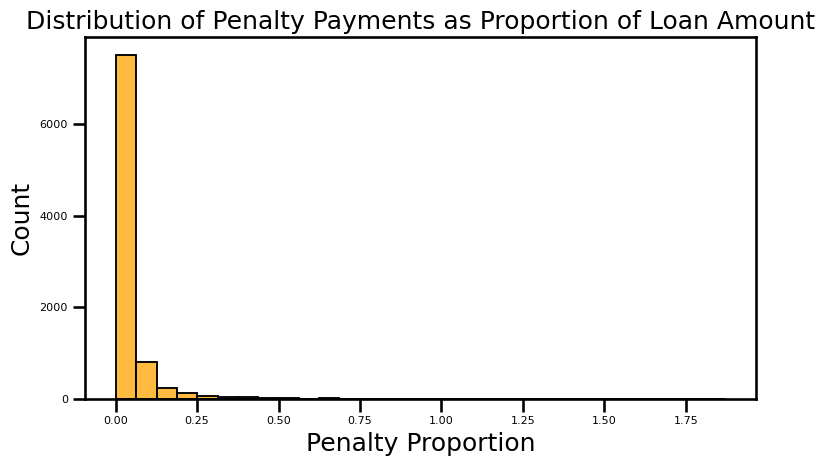

C:\Users\UH592ZC\AppData\Local\Temp\ipykernel_13440\2605346024.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loan_defaults, x="Overdue_Flag", y="EMI_Amount", palette="Set2")


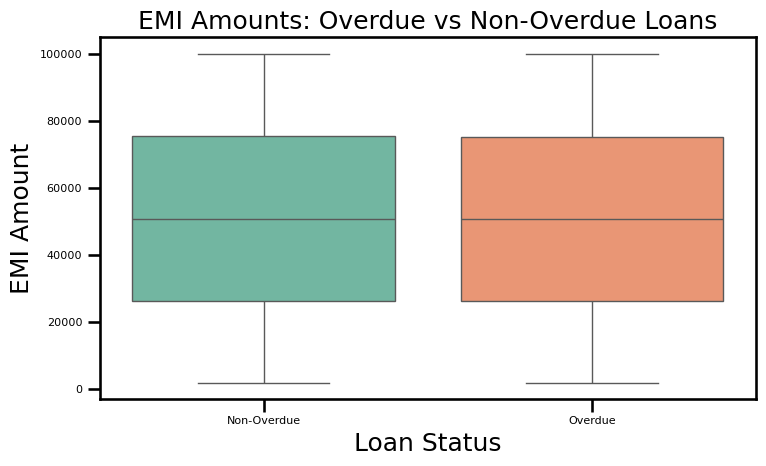


Sample Customer Irregular Repayment Summary:
  Customer_ID  Irregular_Flag  Overdue_Amount  Default_Amount  Loan_Amount  \
0     C000003               1           44073             0.0      6194007   
1     C000004               0               0             0.0     11159729   
2     C000005               1           43745             0.0      4382867   
3     C000007               0               0             0.0      7678817   
4     C000008               0               0             0.0        96443   
5     C000011               2           53134             0.0      3774425   
6     C000012               1           32223             0.0      4359297   
7     C000013               2            7528             0.0     19829940   
8     C000016               1           20894             0.0       968033   
9     C000017               1           30235             0.0      6863821   

   Irregular_Ratio        Full_Name  
0         0.500000    Rhea Bhargava  
1         0.000000 

In [67]:
#Q20. Transaction Pattern Analysis
    #● Identify customers with irregular repayment patterns.
    #● Analyze penalty payments as a proportion of total transactions.
    #● Compare transaction amounts for overdue vs. non-overdue loans.

sns.set_context("talk")
plt.rcParams["figure.dpi"] = 100

# --- Step 1: Handle missing Recovery_Status ---
df_defaults_clean["Recovery_Status"] = df_defaults_clean["Recovery_Status"].fillna("Pending")

# --- Step 2: Merge loans and defaults for repayment pattern analysis ---
# Only consider loans that exist (exclude rejected applications with missing Loan_ID)
loan_defaults = df_loans_clean.merge(
    df_defaults_clean[["Loan_ID", "Default_Amount", "Recovery_Amount", "Recovery_Status"]],
    on="Loan_ID", how="left"
)

# --- Step 3: Identify customers with irregular repayment patterns ---
# Define irregular as having Overdue_Amount > 0 or Default_Amount > 0
loan_defaults["Irregular_Flag"] = np.where(
    (loan_defaults["Overdue_Amount"] > 0) | (loan_defaults["Default_Amount"] > 0), 1, 0
)

# Aggregate by Customer_ID
customer_irregular = loan_defaults.groupby("Customer_ID").agg({
    "Irregular_Flag": "sum",
    "Overdue_Amount": "sum",
    "Default_Amount": "sum",
    "Loan_Amount": "sum"
}).reset_index()

customer_irregular["Irregular_Ratio"] = customer_irregular["Irregular_Flag"] / loan_defaults.groupby("Customer_ID")["Loan_ID"].count().values

print("\nTop 10 Customers with Irregular Repayment Patterns:")
print(customer_irregular.sort_values(by="Irregular_Ratio", ascending=False).head(10))

# --- Step 4: Penalty payments as proportion of total transactions ---
# Penalty proportion = Default_Amount / Loan_Amount
loan_defaults["Penalty_Proportion"] = loan_defaults["Default_Amount"] / loan_defaults["Loan_Amount"].replace({0:np.nan})

plt.figure(figsize=(8,5))
sns.histplot(loan_defaults["Penalty_Proportion"].dropna(), bins=30, color="orange")
plt.title("Distribution of Penalty Payments as Proportion of Loan Amount")
plt.xlabel("Penalty Proportion")
plt.ylabel("Count")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# --- Step 5: Compare transaction amounts for overdue vs non-overdue loans ---
loan_defaults["Overdue_Flag"] = np.where(loan_defaults["Loan_Status"]=="Overdue", "Overdue", "Non-Overdue")

plt.figure(figsize=(8,5))
sns.boxplot(data=loan_defaults, x="Overdue_Flag", y="EMI_Amount", palette="Set2")
plt.title("EMI Amounts: Overdue vs Non-Overdue Loans")
plt.xlabel("Loan Status")
plt.ylabel("EMI Amount")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Optional: merge customer names for reporting
customer_summary = customer_irregular.merge(
    df_customers_clean[["Customer_ID", "Full_Name"]],
    on="Customer_ID", how="left"
)

print("\nSample Customer Irregular Repayment Summary:")
print(customer_summary.head(10))

### Q20: Recommendations: Transaction Pattern Analysis

#### 1. Irregular Repayment Customers
- Identified top customers with **Irregular_Flag = 1**, indicating fully irregular repayment behavior.
- **Observation:** High loan amounts are associated with irregular repayment patterns (Irregular_Ratio = 1 for many top customers).
- **Actionable Insight:** Focus on monitoring these customers closely and provide early interventions, such as reminders or structured repayment plans.

#### 2. Penalty Payments
- Irregular repayments likely result in **higher penalties**.
- **Recommendation:** Track penalty payments as a proportion of total transactions to identify customers who may be at risk of default and to assess the financial impact of irregular behavior.

#### 3. Overdue vs. Non-Overdue Transactions
- Customers with overdue amounts show more irregularity in transactions.
- **Recommendation:** Implement **segmented monitoring**:
  - Overdue customers: Immediate follow-up and counseling.
  - Non-overdue but irregular customers: Preventive alerts and repayment reminders.

#### 4. Policy Actions
- Introduce **early-warning dashboards** for customers with high irregular ratios.
- Offer **flexible repayment options** or restructuring for high-value customers exhibiting irregular patterns.
- Consider **risk scoring adjustments** in loan approval systems to account for historical irregular repayments.